# 📓 Cas d'usage IA — Cibler une campagne de marketing bancaire de manière responsable

**Auteur·e** : Nawelle POLIN
**Promo** : Dev-id — Parcours 2 (Pros IT) 
**Date début** : `04/08/2026`
**Dernière mise à jour** : `08/10/2026`

---

## Présentation du projet

**Le client** : une banque de détail qui démarche ses clients par téléphone pour leur proposer un dépôt à terme. Ces campagnes coûtent cher et ont un faible rendement : seuls **11.3 %** des clients contactés souscrivent.

**L'objectif** : prédire, **avant l'appel**, la probabilité qu'un client souscrive, pour aider les conseillers à prioriser leurs contacts. Le modèle est une **aide à la décision** : la décision d'appeler reste humaine.

**Les données** : dataset public UCI *Bank Marketing* (banque portugaise), 41 188 contacts × 21 variables : profil client, historique de campagne, contexte socio-économique.

**La démarche** : comparer 4 scénarios de variables pour arbitrer entre performance, réalisme et équité :
- retirer `duration` (connue seulement **après** l'appel, donc une fuite d'information) fait passer le F1 de 0.642 à 0.462 ;
- retirer ensuite les variables sensibles (âge, profession, situation familiale, éducation) ne coûte presque rien (F1 0.464).

**Le résultat retenu** : **Scénario 3 + régression logistique**, soit un modèle sans fuite et sans variables sensibles, rapide (1.1 ms/prédiction) et explicable. Ses limites sont mesurées et documentées : reconstruction indirecte de l'âge via le contexte économique (§7.1), disparités résiduelles sur les prédictions (analyse éthique).

**Ce que contient le projet** :
- analyse éthique et réglementaire (biais, RGPD, AI Act) ;
- interprétation du modèle et message client (§7) ;
- API FastAPI testée et conteneurisée avec CI/CD (§8) ;
- monitoring Prometheus/Grafana et analyse de dérive (§9).

**Code source complet** : https://github.com/nawellepolin/cas-usage-certif-bank-marketing-nawelle (`src/`, `app/`, `tests/`). Le journal de bord retrace la démarche séance par séance (Annexe D).


## 🗺️ Mapping sections ↔ compétences ↔ modules

| Section | Étape projet | C tech (CISIA) | CT (transversales OPCO ATLAS) | Modules |
|---|---|---|---|---|
| 1 | Cadrage métier & problème | C1, C2, C4 | **CT3** définir le périmètre · CT4 rechercher méthodiquement | M3, M4, M7, M8 |
| 2 | Identification & acquisition des données | C1 | **CT1** planifier le travail · CT4 | M3, M8 |
| 3 | Exploration & analyse des données | C2, C3 | **CT3** · CT4 | M2, M3 |
| 4 | Préparation des données | C3 | **CT1** · CT4 | M2, M3 |
| 5 | Modélisation & entraînement | C4, C5 | **CT4** · CT3 (périmètre du problème ML) | M1, M4, M6 |
| 6 | Analyse des scénarios & arbitrages | C2, C4 | **CT5** partager la solution | M2, M4, M7 |
| 7 | Interprétation pour la communication client (soutenance) | C8 | **CT6** présenter au commanditaire · CT5 documenter | M6, M9 |
| 8 | Industrialisation (API, UI, conteneurs) | C6, C7 | **CT5** documenter | M0, M1, M5, M7 |
| 9 | Suivi en production & amélioration continue | C8, C9 | **CT2** contribuer au pilotage · CT9 faciliter le travail collectif | M5, M6 |

**Légende** : **CT en gras** = dominante (cœur de la section) · CT en normal = mobilisée. **2 CT max par section** — pas de CT en arrière-plan, on cible le cœur.

### 👀 CT non couvertes par le notebook (à évaluer en formation)

Le notebook ne suffit pas pour évaluer toutes les compétences transversales. **CT7, CT8 et CT9 s'observent en formation**, pas dans le notebook :

| CT | Description | Observable où ? |
|---|---|---|
| **CT7** | Se familiariser avec la culture pro IA | Veille collective Notion (mercredi midi), restitutions mercredi, RDV individuels vendredi |
| **CT8** | Interactions respectueuses & constructives | Briefs en binôme : M0-B2, M2-B2, M3-B2, M5-B1, M6-B1, M7-B2, M8-B2 |
| **CT9** | Faciliter le travail collectif | Brief en groupe M6-B2 + mur réflexif + restitutions orales |

> 📋 Côté formatrice : une **grille d'observation pédagogique séparée** suit CT7-CT8-CT9 en parallèle de ce notebook (à produire avant J1).


## 0. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

sys.path.insert(0, "..")
# Avertissement interne sklearn/joblib sans incidence (pas une erreur) qui se répète à
# chaque appel parallèle (n_jobs=-1) — sans ce filtre, la mesure de latence ligne-par-
# ligne en §6.4 noie le notebook sous des Mo de bruit stderr identique.
warnings.filterwarnings("ignore", message=r".*should be used with.*Parallel.*", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 0.5 Traçabilité de la session

Trois éléments figés pour que l'analyse soit reproductible :
- la **version du dataset** (source, date d'extraction, hash),
- les **versions des libs** (cf. `requirements.txt` du repo associé),
- le **commit Git** du repo associé au notebook.

In [2]:
import sys
import subprocess
import hashlib
from datetime import datetime

DATASET_NAME = "UCI Bank Marketing — bank-additional-full.csv"
DATASET_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing (fichier fourni par la formation, dossier consigne/ de l'examen)"
DATASET_RECEIVED = "2026-08-04"

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date d'exécution : {datetime.now().isoformat(timespec='minutes')}")
print(f"Python           : {sys.version.split()[0]}")
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Git commit       : {git_commit}")
print(f"Dataset          : {DATASET_NAME}")
print(f"  source         : {DATASET_SOURCE}")
print(f"  reçu le        : {DATASET_RECEIVED}")
print(f"  sha256         : {file_sha256(DATA_DIR / 'bank-additional-full.csv') if 'DATA_DIR' in dir() else file_sha256('../data/bank-additional-full.csv')}")

Date d'exécution : 2026-10-09T12:44
Python           : 3.12.14
NumPy            : 2.5.3
Pandas           : 3.0.6
Git commit       : ce04a184
Dataset          : UCI Bank Marketing — bank-additional-full.csv
  source         : https://archive.ics.uci.edu/dataset/222/bank+marketing (fichier fourni par la formation, dossier consigne/ de l'examen)
  reçu le        : 2026-08-04
  sha256         : 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une banque de détail (banque portugaise, cas UCI Bank Marketing) qui mène des campagnes de démarchage téléphonique pour proposer des produits d'épargne (dépôts à terme) à ses clients. Ces campagnes ont un coût élevé (temps des conseillers, plateformes d'appel) et, mal ciblées, elles saturent les clients d'appels non pertinents — ce qui dégrade la relation commerciale en plus de représenter un coût direct. La banque souhaite identifier, **avant** de lancer un appel, les clients les plus susceptibles de souscrire, afin de concentrer l'effort commercial sur les bons profils.

### 1.2 Énoncé du problème IA

Prédire, pour un client donné, la probabilité qu'il souscrive à un dépôt à terme (variable cible `y`, oui/non), à partir des informations disponibles **avant** la réalisation de l'appel (profil socio-démographique, historique des contacts précédents, contexte socio-économique) — à l'exclusion de toute information connue seulement après l'appel (ex. sa durée). C'est une tâche de **classification binaire**, dont la sortie (une probabilité) sert à décider, en amont, qui contacter en priorité.

### 1.3 Bénéficiaires & impacts

- **Bénéficiaires directs** : le conseiller bancaire (qui priorise ses appels) et le responsable de campagne marketing (qui pilote l'allocation des ressources).
- **Bénéficiaires / impactés indirects** : les clients de la banque. Positivement, un client intéressé est contacté au bon moment, et un client non intéressé est moins sollicité. Négativement, un client réellement susceptible de souscrire mais mal noté par le modèle (faux négatif) perd une opportunité d'être contacté ; un client mal noté positivement (faux positif) subit un appel inutile.

### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA/modélisation | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire le nombre d'appels "inutiles" sans perdre de souscripteurs potentiels | ex. -20 % d'appels à nombre de souscriptions égal | Non quantifiable en "-20 % d'appels" tel quel : avec le modèle retenu (Scénario 3, seuil 0.5), appeler les clients priorisés fait passer le taux de réussite par appel de 11.3 % (hasard) à 36.3 % (précision du modèle) — un effort **~3.2 fois mieux ciblé**, formulation plus fidèle à ce que le modèle peut réellement garantir | La cible initiale ("-20 % d'appels") supposait implicitement un modèle quasi parfait ; le vrai levier mesuré est la **concentration de l'effort**, pas une réduction de volume à souscriptions égales |
| Modèle | Rappel / F1-score sur la classe "oui" (minoritaire, ~11 %) — pas l'accuracy | F1 classe positive ≥ 0.50 (hypothèse de départ, sans baseline) | F1 = **0.464** (Scénario 3, test set) — sous l'hypothèse initiale de 0.50 | Le déséquilibre (11.3 %) et surtout le retrait nécessaire de `duration` (fuite, §1.2) coûtent 28 points de F1 à eux seuls (0.642 → 0.462, cf. §5.7) ; 0.50 était une estimation optimiste avant d'avoir mesuré le prix de la conformité méthodologique |
| Opérationnel | Latence de l'API de prédiction | < 1 s par requête (usage non temps-réel : le conseiller consulte avant d'appeler) | **1.1 ms** mesurée (§6.1, §8.2) — très largement sous la cible initiale | Cible initiale fixée par prudence sans mesure ; un modèle linéaire aussi simple n'avait pas besoin d'une contrainte aussi large, confirmé une fois construit et chronométré |

### 1.5 Risques éthiques & réglementaires anticipés

Plusieurs variables socio-démographiques sont potentiellement discriminantes pour un usage commercial : âge, profession (`job`), situation familiale (`marital`), niveau d'éducation (`education`). **Aucune de ces variables ne relève des "catégories particulières" de l'article 9 du RGPD** (santé, origine, opinions politiques/religieuses, orientation sexuelle, données biométriques/génétiques) — ce sont des données personnelles "classiques", mais leur usage pour cibler une offre commerciale pose un risque de **discrimination indirecte** (ex. exclure systématiquement certaines catégories socio-professionnelles ou tranches d'âge de l'offre).

Question à instruire en §4.3/§6 : certaines de ces variables sont-elles redondantes avec d'autres (ex. `job` et `education` corrélées) au point de pouvoir être retirées sans perte de performance significative ? Si oui, cela renforce l'argument de les exclure (Scénario 3). Par ailleurs, `default` / `housing` / `loan` touchent à la situation financière du client — également sensible du point de vue de la vulnérabilité économique, à surveiller dans l'analyse de biais (§3.6).

### 1.6 Synthèse cadrage

Problème : prédire la souscription à un dépôt à terme à partir d'informations disponibles **avant** l'appel, pour prioriser les appels d'une campagne de démarchage téléphonique. Tâche IA : classification binaire supervisée. Critère dominant : rappel/F1 sur la classe minoritaire "oui" plutôt que l'accuracy. Risque éthique principal identifié à ce stade : usage de variables socio-démographiques (âge, job, situation familiale, éducation) pour un ciblage commercial, avec un risque de discrimination indirecte à vérifier empiriquement (§3.6, §6, analyse éthique finale).

---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| UCI Machine Learning Repository — Bank Marketing (fourni par la formation) | Fichier plat | 41 188 lignes × 21 colonnes (20 variables + cible `y`) | CSV, séparateur `;` | Fourni directement dans le dossier `consigne/` de l'examen | 04/08/2026 (récupération du fichier fourni par la formation) |

Source originale du dataset : [UCI ML Repository — Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing).

In [3]:
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "bank-additional-full.csv", sep=";")
print(df.shape)
df.columns.tolist()

(41188, 21)


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `age` | Âge du client | numérique | - | non | **oui** — proxy direct d'âge |
| `job` | Type d'emploi | catégoriel (12 modalités) | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown | non | **oui** — proxy socio-pro |
| `marital` | Statut marital | catégoriel | married, single, divorced (incl. veufs), unknown | non | **oui** |
| `education` | Niveau d'éducation | catégoriel (8 modalités) | basic.4y/6y/9y, high.school, illiterate, professional.course, university.degree, unknown | non | **oui** |
| `default` | Crédit en défaut ? | catégoriel | yes/no/unknown | non | sensible (situation financière) |
| `housing` | Prêt immobilier ? | catégoriel | yes/no/unknown | non | sensible (situation financière) |
| `loan` | Prêt personnel ? | catégoriel | yes/no/unknown | non | sensible (situation financière) |
| `contact` | Moyen de contact | catégoriel | cellular, telephone | non | non |
| `month` | Mois du dernier contact | catégoriel | jan...dec | non | non |
| `day_of_week` | Jour du dernier contact | catégoriel | mon...fri | non | non |
| `duration` | Durée du dernier appel (s) | numérique | - | non | **fuite d'info potentielle** — connue seulement après l'appel (cf. §1.2, Scénario 2) |
| `campaign` | Nb de contacts cette campagne | numérique | inclut le dernier contact | non | non |
| `pdays` | Jours depuis dernier contact (campagne précédente) | numérique | 999 = jamais recontacté | non | non |
| `previous` | Nb de contacts avant cette campagne | numérique | - | non | non |
| `poutcome` | Résultat campagne précédente | catégoriel | failure, nonexistent, success | non | non |
| `emp.var.rate` | Taux de variation de l'emploi | numérique (contexte, trimestriel) | - | non | non |
| `cons.price.idx` | Indice des prix à la consommation | numérique (contexte, mensuel) | - | non | non |
| `cons.conf.idx` | Indice de confiance des consommateurs | numérique (contexte, mensuel) | - | non | non |
| `euribor3m` | Taux Euribor 3 mois | numérique (contexte, journalier) | - | non | non |
| `nr.employed` | Nombre de salariés | numérique (contexte, trimestriel) | - | non | non |
| `y` | Souscription au dépôt à terme | catégoriel binaire | yes/no | **oui** | - |

---
## 3. Exploration & analyse des données (EDA)

In [4]:
display(df.head())
df.info()
df.describe(include="all").T

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Lignes dupliquées :", df.duplicated().sum())
print("Valeurs manquantes (NaN) :", df.isna().sum().sum())
print()

cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Taux de modalité 'unknown' par variable catégorielle :")
for c in cat_cols:
    taux = (df[c] == "unknown").mean()
    if taux > 0:
        print(f"  {c:15s} {taux*100:5.2f} %")
print()

print(f"pdays == 999 : {(df['pdays']==999).mean()*100:.1f} % des lignes")
print(f"duration == 0 : {(df['duration']==0).sum()} lignes, "
      f"toutes y == 'no' : {(df.loc[df['duration']==0, 'y']=='no').all()}")

Lignes dupliquées : 12
Valeurs manquantes (NaN) : 0

Taux de modalité 'unknown' par variable catégorielle :
  job              0.80 %
  marital          0.19 %
  education        4.20 %
  default         20.87 %
  housing          2.40 %
  loan             2.40 %

pdays == 999 : 96.3 % des lignes
duration == 0 : 4 lignes, toutes y == 'no' : True


/var/folders/77/lnt41f0d22s5vkqgcf4wpghc0000gn/T/ipykernel_51230/1399222014.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


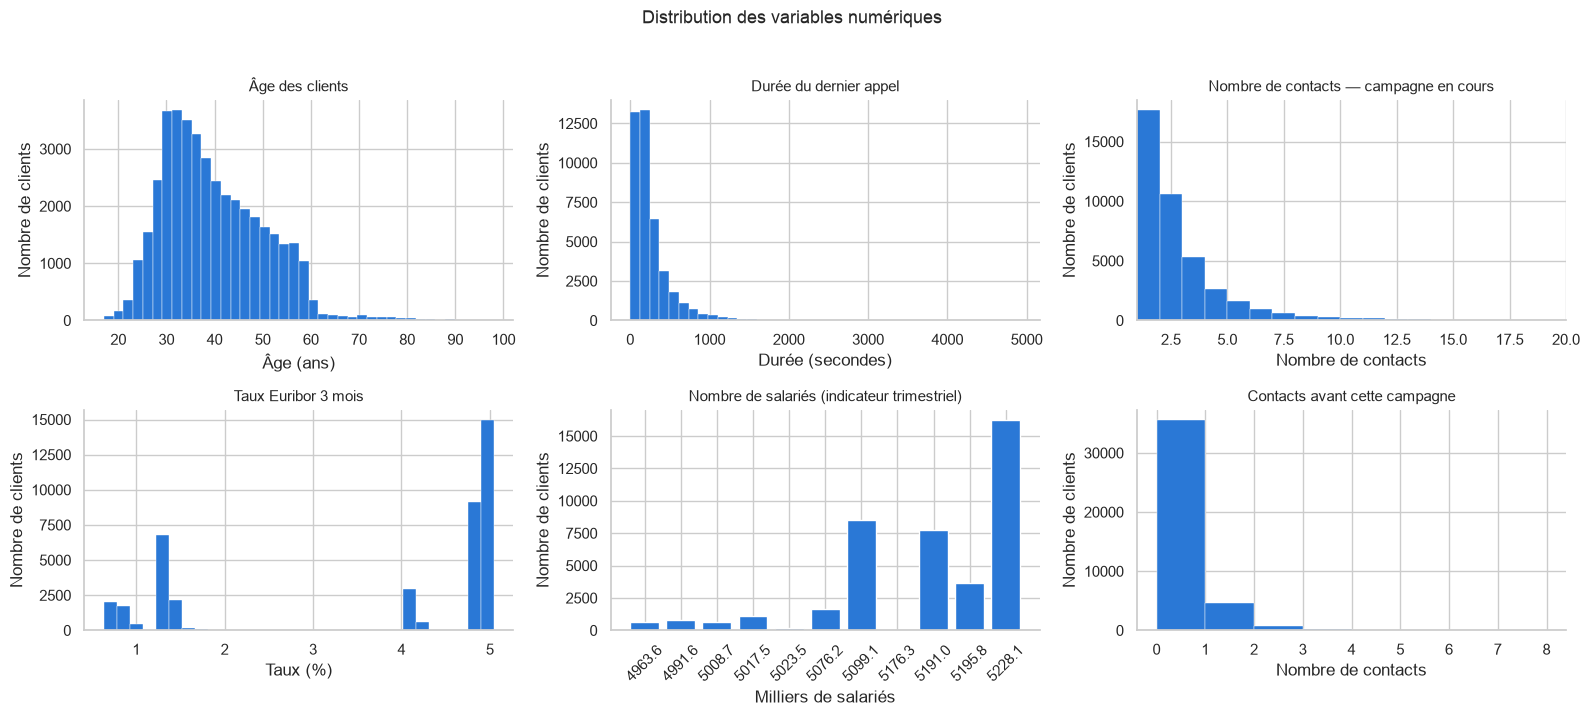

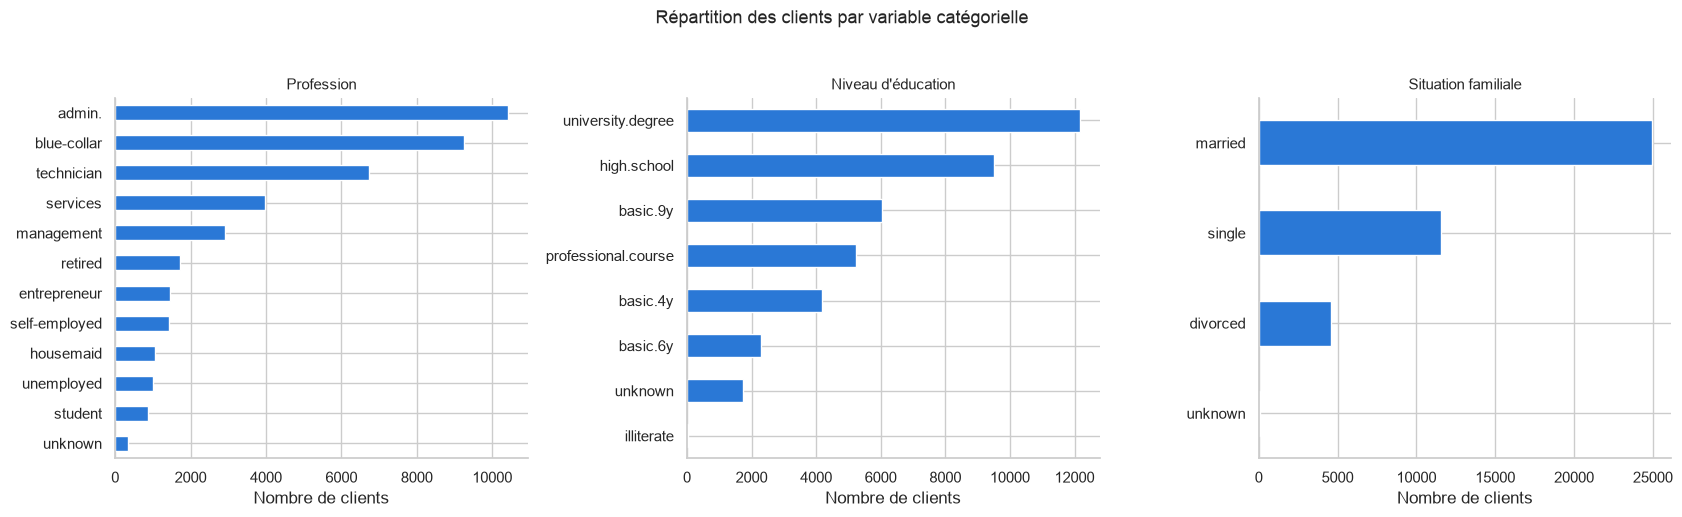

In [6]:
BLUE = "#2a78d6"

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

df["age"].hist(bins=40, ax=axes[0, 0], color=BLUE, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("Âge des clients", fontsize=11)
axes[0, 0].set_xlabel("Âge (ans)")

df["duration"].hist(bins=40, ax=axes[0, 1], color=BLUE, edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("Durée du dernier appel", fontsize=11)
axes[0, 1].set_xlabel("Durée (secondes)")

axes[0, 2].hist(df["campaign"], bins=range(1, df["campaign"].max() + 2), color=BLUE, edgecolor="white", linewidth=0.3)
axes[0, 2].set_title("Nombre de contacts — campagne en cours", fontsize=11)
axes[0, 2].set_xlabel("Nombre de contacts")
axes[0, 2].set_xlim(1, 20)

df["euribor3m"].hist(bins=30, ax=axes[1, 0], color=BLUE, edgecolor="white", linewidth=0.3)
axes[1, 0].set_title("Taux Euribor 3 mois", fontsize=11)
axes[1, 0].set_xlabel("Taux (%)")

vc = df["nr.employed"].value_counts().sort_index()
axes[1, 1].bar(vc.index.astype(str), vc.values, color=BLUE)
axes[1, 1].set_title("Nombre de salariés (indicateur trimestriel)", fontsize=11)
axes[1, 1].set_xlabel("Milliers de salariés")
axes[1, 1].tick_params(axis="x", rotation=45)

axes[1, 2].hist(df["previous"], bins=range(0, df["previous"].max() + 2), color=BLUE, edgecolor="white", linewidth=0.3)
axes[1, 2].set_title("Contacts avant cette campagne", fontsize=11)
axes[1, 2].set_xlabel("Nombre de contacts")

for ax in axes.flat:
    ax.set_ylabel("Nombre de clients")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Distribution des variables numériques", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

cat_specs = [("job", "Profession"), ("education", "Niveau d'éducation"), ("marital", "Situation familiale")]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (col, title) in zip(axes, cat_specs):
    counts = df[col].value_counts().sort_values()
    counts.plot(kind="barh", ax=ax, color=BLUE)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Nombre de clients")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Répartition des clients par variable catégorielle", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

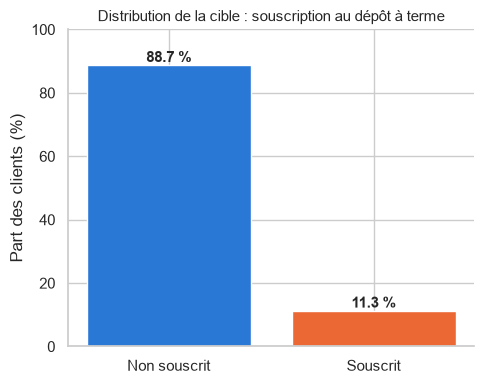

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [7]:
BLUE, ORANGE = "#2a78d6", "#eb6834"

vc = df["y"].value_counts(normalize=True).reindex(["no", "yes"])
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Non souscrit", "Souscrit"], vc.values * 100, color=[BLUE, ORANGE])
for bar, pct in zip(bars, vc.values * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{pct:.1f} %", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Part des clients (%)")
ax.set_title("Distribution de la cible : souscription au dépôt à terme", fontsize=11)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(vc)

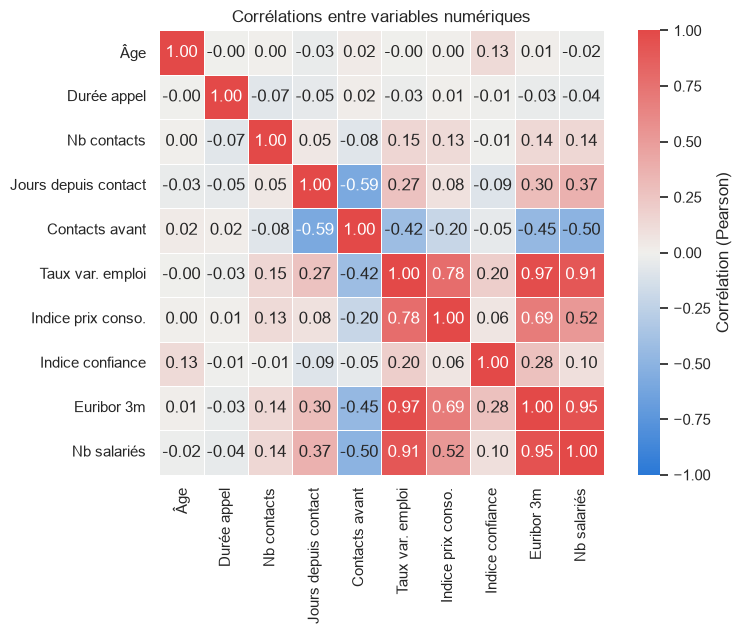

Indicateurs socio-économiques très corrélés entre eux :
              emp.var.rate  euribor3m  nr.employed
emp.var.rate         1.000      0.972        0.907
euribor3m            0.972      1.000        0.945
nr.employed          0.907      0.945        1.000

Recoupement job × education (part de chaque niveau d'éducation au sein du métier) :


education,university.degree,basic.4y,professional.course
job,,,
admin.,0.55,0.01,0.03
blue-collar,0.01,0.25,0.05
entrepreneur,0.42,0.09,0.09
housemaid,0.13,0.45,0.06
management,0.71,0.03,0.03
retired,0.17,0.35,0.14
self-employed,0.54,0.07,0.12
services,0.04,0.03,0.05
student,0.19,0.03,0.05


In [8]:
from matplotlib.colors import LinearSegmentedColormap

diverging = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"]
)

num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
labels = ["Âge", "Durée appel", "Nb contacts", "Jours depuis contact", "Contacts avant",
          "Taux var. emploi", "Indice prix conso.", "Indice confiance", "Euribor 3m", "Nb salariés"]

corr = df[num_cols].corr()
corr.index = corr.columns = labels

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=diverging, center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Corrélation (Pearson)"})
plt.title("Corrélations entre variables numériques", fontsize=12)
plt.tight_layout()
plt.show()

print("Indicateurs socio-économiques très corrélés entre eux :")
print(df[["emp.var.rate", "euribor3m", "nr.employed"]].corr().round(3))
print()
print("Recoupement job × education (part de chaque niveau d'éducation au sein du métier) :")
pd.crosstab(df["job"], df["education"], normalize="index").round(2)[
    ["university.degree", "basic.4y", "professional.course"]
]

### 3.6 Analyse des biais & variables sensibles

**Disparate impact (règle des 4/5, EEOC 1978)** — même méthode qu'en M2-B1 (`02_Disparate_impact_essentiel.md`) : taux de sélection (ici, taux de souscription réelle) par groupe, ratio min/max. DI < 0.8 = signal de discrimination indirecte à documenter.

In [9]:
sr_job = df.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values()
di_job = sr_job.min() / sr_job.max()
print("Taux de souscription par profession :")
print(sr_job.round(3))
print(f"DI job = {di_job:.3f}  (min={sr_job.idxmin()}, max={sr_job.idxmax()})",
      "-> signal (< 0.8)" if di_job < 0.8 else "-> pas de signal 4/5")
print()

bins = [17, 25, 35, 45, 55, 65, 99]
age_bucket = pd.cut(df["age"], bins=bins)
sr_age = df.groupby(age_bucket, observed=True)["y"].apply(lambda s: (s == "yes").mean())
di_age = sr_age.min() / sr_age.max()
print("Taux de souscription par tranche d'âge :")
print(sr_age.round(3))
print(f"DI âge = {di_age:.3f}  (min={sr_age.idxmin()}, max={sr_age.idxmax()})",
      "-> signal (< 0.8)" if di_age < 0.8 else "-> pas de signal 4/5")

Taux de souscription par profession :
job
blue-collar      0.069
services         0.081
entrepreneur     0.085
housemaid        0.100
self-employed    0.105
technician       0.108
unknown          0.112
management       0.112
admin.           0.130
unemployed       0.142
retired          0.252
student          0.314
Name: y, dtype: float64
DI job = 0.219  (min=blue-collar, max=student) -> signal (< 0.8)

Taux de souscription par tranche d'âge :
age
(17, 25]    0.209
(25, 35]    0.117
(35, 45]    0.085
(45, 55]    0.087
(55, 65]    0.152
(65, 99]    0.468
Name: y, dtype: float64
DI âge = 0.182  (min=(35, 45], max=(65, 99]) -> signal (< 0.8)


**Verdict** : DI job = **0.219**, DI âge = **0.182** — très largement sous le seuil de 0.8.

⚠️ **Précision importante** : ce DI est calculé sur le *comportement historique des clients* (ont-ils souscrit, oui/non), pas sur une décision de la banque. À ce stade, personne ne "traite" personne différemment — c'est un fait observé, pas un acte discriminatoire en soi.

**Où se situe le vrai risque éthique** : dans l'usage qu'on va en faire. Dès qu'un modèle s'appuie sur ce schéma pour décider qui appeler, la banque devient actrice de la décision — et répète à grande échelle un écart qui n'était jusque-là qu'une observation passive. Pire : si la banque cesse de démarcher les `blue-collar` parce que le modèle les juge peu rentables, ces clients n'ont plus jamais l'occasion de contredire cette prédiction — l'écart s'auto-confirme dans les données futures (boucle de rétroaction), qu'il reflète un vrai désintérêt ou un simple manque d'opportunité.

**Conclusion** : le DI sur les données historiques est une **alerte à surveiller**, pas une accusation portée sur la donnée elle-même. Il justifie qu'on teste un Scénario sans ces variables (Scénario 3) et qu'on mesure, une fois un modèle entraîné, si ses *prédictions* reproduisent un écart de sélection comparable entre groupes (partie Analyse éthique du sujet) — c'est à ce niveau-là, celui de la décision automatisée, que la question "discriminatoire ou non" se pose vraiment.

### 3.7 Synthèse EDA

**Top enseignements :**
1. **Déséquilibre de la cible** : 11.3 % de "yes" / 88.7 % de "no" — confirmé, conforme au sujet. L'accuracy sera trompeuse ; on retient F1/rappel sur la classe "yes" et ROC-AUC (cf. §1.4).
2. **Qualité des données globalement bonne** : 12 doublons seulement (négligeable, à retirer en §4), aucun NaN technique, mais des `"unknown"` fréquents sur `default` (20.9 %, à traiter comme une modalité à part entière, pas à imputer) et dans une moindre mesure `education` (4.2 %).
3. **`pdays` est dégénérée à 96.3 %** (valeur 999 = jamais recontacté) : peu informative telle quelle, candidate à une transformation en indicateur binaire "déjà contacté avant" (§4.2).
4. **Les 4 indicateurs socio-économiques sont fortement colinéaires** (`emp.var.rate` / `euribor3m` / `nr.employed` corrélés > 0.9) : point de vigilance pour la régression logistique (coefficients instables), moins problématique pour les modèles à base d'arbres.
5. **`job` et `education` se recoupent fortement**, et l'âge a une relation en U avec la cible qui recoupe en partie `job` — argument concret pour le Scénario 3 (retrait des variables sensibles), à quantifier en comparant les performances.

**Hypothèses de travail pour la modélisation :**
- Baseline avec `class_weight="balanced"` ou seuil ajusté plutôt que seuil 0.5 par défaut (déséquilibre 11 %).
- `duration` sera isolée dès le pipeline de préparation (Scénario 1 vs 2) — c'est la variable la plus prédictive mais non disponible avant l'appel (cf. §1.2).
- `pdays` (dégénérée à 96.3 % sur la valeur 999) : le sentinelle 999 est recodé en valeur manquante puis imputé par la médiane des vraies valeurs (sur le train), en plus de l'indicateur binaire `has_prior_contact` — on garde ainsi la récence réelle du contact pour les clients concernés plutôt que de la perdre (cf. §4).

**Risques de biais identifiés** : âge et profession corrélés à la cible de façon non uniforme (actifs 35-55 ans sous-représentés parmi les souscripteurs) — à surveiller via les métriques par sous-groupe une fois un modèle entraîné.

**Révision de §1.4** : le critère modèle "F1 classe positive ≥ 0.50" reste une hypothèse raisonnable de départ vu le déséquilibre observé ; à confirmer avec une baseline réelle en §5.

---
## 4. Préparation des données

In [10]:
from src.preprocess import add_engineered_features

print("Doublons retirés :", df.duplicated().sum())
df_clean = df.drop_duplicates().reset_index(drop=True)
df_fe = add_engineered_features(df_clean)

X = df_fe.drop(columns=["y"])
y = (df_fe["y"] == "yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train :", X_train.shape, "taux positif :", y_train.mean().round(4))
print("Test  :", X_test.shape, "taux positif :", y_test.mean().round(4))

Doublons retirés : 12
Train : (32940, 21) taux positif : 0.1127
Test  : (8236, 21) taux positif : 0.1127


In [11]:
from src.preprocess import make_preprocessor, get_scenario_columns, SCENARIOS

for scenario in SCENARIOS:
    cat_cols, num_cols = get_scenario_columns(scenario)
    print(f"{scenario:12s} -> {len(cat_cols) + len(num_cols):2d} colonnes "
          f"({len(cat_cols)} catégorielles + {len(num_cols)} numériques)")

scenario_1   -> 21 colonnes (10 catégorielles + 11 numériques)
scenario_2   -> 20 colonnes (10 catégorielles + 10 numériques)
scenario_3   -> 13 colonnes (4 catégorielles + 9 numériques)
scenario_4   ->  8 colonnes (3 catégorielles + 5 numériques)


### 4.3 Scénarios de jeux de données

| Scénario | Retrait par rapport au précédent | Colonnes | Justification |
|---|---|---|---|
| **1 — Référence** | Aucun (toutes les variables, y compris `duration`) | 21* | Performance de référence, y compris la fuite d'information |
| **2 — Sans `duration`** | `duration` | 20 | `duration` n'est connue qu'après l'appel (§1.2) — fuite d'information vis-à-vis de l'usage réel (décider qui appeler avant l'appel) |
| **3 — Sans variables sensibles** | + `age`, `job`, `marital`, `education`, `default`, `housing`, `loan` | 13 | Risque de discrimination indirecte dans un ciblage commercial (§1.5) ; `job` et `education` sont retirées **ensemble** malgré (et à cause de) leur forte redondance (§3.6) — n'en retirer qu'une laisserait l'autre reconstruire l'essentiel du signal retiré (discrimination par proxy) ; `default`/`housing`/`loan` touchent à la vulnérabilité financière du client |
| **4 — Socle minimal (optionnel)** | + `campaign`, `pdays`, `previous`, `poutcome`, `has_prior_contact` | 8 | Teste la faisabilité d'un modèle reposant uniquement sur le contexte de contact (canal, période) et le contexte socio-économique, sans aucun historique de campagne ni variable sensible |

*21 = 20 variables explicatives d'origine + `has_prior_contact` (indicateur dérivé de `pdays`, cf. `src/preprocess.py`) ; `pdays` elle-même est conservée (999 → valeur manquante → imputée par la médiane du train), pas de perte d'information sur la récence du contact.

La fonction `make_preprocessor(scenario)` (§4.2) applique le **même traitement** (one-hot encoding des catégorielles, imputation + standardisation des numériques) aux 4 scénarios — seul le périmètre des colonnes change, pas la logique de transformation.

### 4.5 Assertions de qualité

In [12]:
from src.preprocess import get_scenario_columns

assert df_fe.shape[0] > 0, "Dataset vide après préparation"
assert y.isna().sum() == 0, "Valeurs manquantes dans la cible"
assert set(y.unique()) == {0, 1}, "Cible non binaire"
assert X_train.shape[0] + X_test.shape[0] == df_fe.shape[0], "Perte de lignes au split"
assert abs(y_train.mean() - y.mean()) < 0.01, "Stratification du split incorrecte"

for scenario in SCENARIOS:
    cat_cols, num_cols = get_scenario_columns(scenario)
    cols = set(cat_cols) | set(num_cols)
    assert cols <= set(X_train.columns), f"{scenario} référence une colonne absente de X"
    assert "duration" not in cols or scenario == "scenario_1", f"{scenario} ne doit pas contenir duration"
    sensitive = {"age", "job", "marital", "education", "default", "housing", "loan"}
    if scenario in ("scenario_3", "scenario_4"):
        assert not (cols & sensitive), f"{scenario} contient encore une variable sensible"

print("Assertions de qualité : OK")

Assertions de qualité : OK


---
## 5. Modélisation & entraînement

### 5.0 Familles de modèles candidates

| Famille | Retenue ? | Pourquoi |
|---|---|---|
| **Linéaire (régression logistique)** | ✅ | Imposée par le sujet comme référence ; rapide, interprétable |
| **Ensemble d'arbres (Random Forest)** | ✅ | Imposée par le sujet (alternative arbre/forêt) ; capture les interactions non-linéaires, robuste à la colinéarité des indicateurs socio-éco (§3.5) |
| **Arbre de décision unique** | ❌ écartée | Dominée par la forêt aléatoire (moyennage de plusieurs arbres = moins de surapprentissage) pour un coût d'inférence comparable |
| **Gradient boosting** | ❌ hors périmètre | Hors du périmètre demandé par le sujet (logreg + arbre/forêt) ; piste bonus possible si le temps le permet |
| **Deep learning** | ❌ écartée | ~41k lignes de données tabulaires : ni le volume ni la nature de la donnée ne le justifient (sobriété, même logique que le choix M4) |
| **SLM / LLM+RAG / agents** | ❌ écartée | Hors sujet : classification tabulaire structurée, pas de texte libre ni de tâche générative |

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| `LogisticRegression` (`class_weight="balanced"`) | Linéaire | Baseline de référence demandée par le sujet ; rapide à entraîner et à expliquer | Très faible / quasi instantané | Haute — coefficients directement lisibles (prudence sur les indicateurs socio-éco corrélés, §3.5) |
| `RandomForestClassifier` (`class_weight="balanced"`, 200 arbres) | Ensemble d'arbres | Capture les interactions non-linéaires, robuste à la colinéarité et aux `unknown` encodés comme catégorie | Modéré à l'entraînement / rapide à l'inférence | Moyenne — feature importance native, approfondie en §7.1 |

`class_weight="balanced"` sur les deux modèles plutôt qu'un seuil par défaut à 0.5 : compense le déséquilibre (11 % de classe positive) directement dans l'apprentissage plutôt qu'en post-traitement.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

MODELS = {
    "logreg": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["f1", "roc_auc", "recall", "precision", "accuracy"]

rows = []
for scenario in SCENARIOS:
    preprocessor = make_preprocessor(scenario)
    for model_name, model in MODELS.items():
        pipe = Pipeline([("prep", preprocessor), ("clf", model)])
        scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"scenario": scenario, "model": model_name}
        for m in scoring:
            row[f"{m}_mean"] = scores[f"test_{m}"].mean()
            row[f"{m}_std"] = scores[f"test_{m}"].std()
        rows.append(row)

cv_results = pd.DataFrame(rows)
cv_results.sort_values(["scenario", "f1_mean"], ascending=[True, False]).round(3)

,scenario,model,f1_mean,f1_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,accuracy_mean,accuracy_std
1,scenario_1,random_forest,0.630,0.007,0.943,0.002,0.721,0.015,0.560,0.010,0.905,0.002
0,scenario_1,logreg,0.586,0.008,0.937,0.002,0.882,0.005,0.439,0.009,0.860,0.005
3,scenario_2,random_forest,0.450,0.007,0.776,0.006,0.461,0.007,0.440,0.014,0.873,0.004
2,scenario_2,logreg,0.450,0.008,0.791,0.008,0.623,0.013,0.352,0.007,0.829,0.003
4,scenario_3,logreg,0.450,0.008,0.791,0.006,0.617,0.015,0.354,0.006,0.830,0.003
5,scenario_3,random_forest,0.403,0.011,0.738,0.009,0.536,0.020,0.324,0.008,0.822,0.003
7,scenario_4,random_forest,0.474,0.009,0.782,0.006,0.589,0.022,0.396,0.010,0.853,0.005
6,scenario_4,logreg,0.453,0.009,0.783,0.005,0.600,0.014,0.364,0.007,0.837,0.003


**Repère "plancher"** : avant de juger les modèles entraînés, on se donne une référence triviale — un `DummyClassifier` qui prédit toujours la classe majoritaire ("no"). Tout modèle qui ne bat pas ça n'a rien appris.

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, recall_score, precision_score

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Dummy (toujours 'no') — accuracy : {(y_pred_dummy == y_test).mean():.4f}")
print(f"Dummy (toujours 'no') — F1 (classe yes) : {f1_score(y_test, y_pred_dummy):.4f}")

Dummy (toujours 'no') — accuracy : 0.8873
Dummy (toujours 'no') — F1 (classe yes) : 0.0000


**Lecture** : le plancher a 88.7% d'accuracy et **0.0 de F1** — exactement l'illustration du piège que le sujet signale. Tous nos modèles (F1 de 0.46 à 0.64 selon le scénario) battent largement ce plancher : ils apprennent réellement un signal, pas seulement la fréquence de la classe majoritaire.

### 5.3 Métriques retenues & justification

- **F1 (classe "yes")** — métrique de décision principale : équilibre précision et rappel sur la classe minoritaire (11 %), là où l'accuracy ne dit rien d'utile (cf. "à surveiller" du sujet).
- **ROC-AUC** — mesure la séparabilité indépendamment d'un seuil, utile pour comparer des modèles avant de fixer un seuil de décision opérationnel (§7).
- **Rappel** et **précision** rapportés séparément : rappel = part des vrais souscripteurs qu'on ne rate pas (coût = opportunité commerciale perdue) ; précision = part des clients appelés qui souscrivent réellement (coût = appels inutiles, cf. contexte du sujet).
- **Accuracy** calculée mais **jamais utilisée pour décider** : elle reste élevée (82-90 %) même pour les scénarios les plus faibles — exactement le piège que le sujet demande d'éviter.

`class_weight="balanced"` sur les deux modèles plutôt qu'un seuil à 0.5 arbitraire : le modèle apprend directement avec le déséquilibre plutôt que de le corriger après coup.

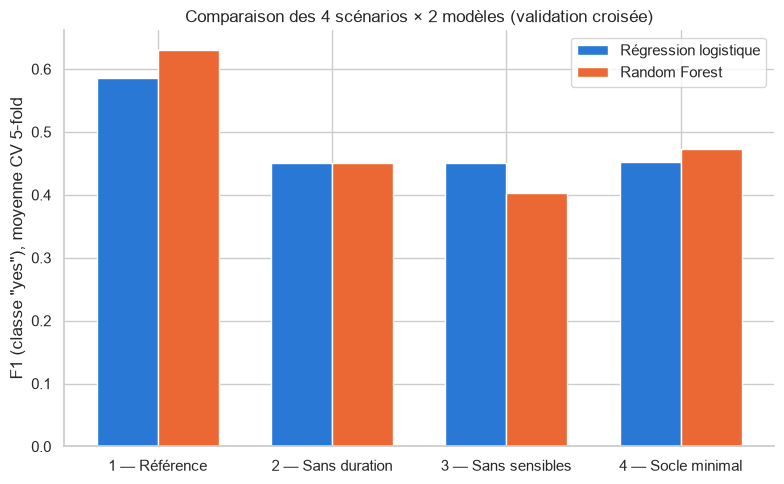

model,logreg,random_forest
scenario,,
scenario_1,0.586,0.630
scenario_2,0.450,0.450
scenario_3,0.450,0.403
scenario_4,0.453,0.474


In [15]:
BLUE, ORANGE = "#2a78d6", "#eb6834"

pivot = cv_results.pivot(index="scenario", columns="model", values="f1_mean")
pivot = pivot.loc[SCENARIOS, ["logreg", "random_forest"]]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(pivot))
width = 0.35
ax.bar(x - width/2, pivot["logreg"], width, label="Régression logistique", color=BLUE)
ax.bar(x + width/2, pivot["random_forest"], width, label="Random Forest", color=ORANGE)
ax.set_xticks(x)
ax.set_xticklabels(["1 — Référence", "2 — Sans duration", "3 — Sans sensibles", "4 — Socle minimal"])
ax.set_ylabel("F1 (classe \"yes\"), moyenne CV 5-fold")
ax.set_title("Comparaison des 4 scénarios × 2 modèles (validation croisée)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

cv_results.pivot(index="scenario", columns="model", values="f1_mean").loc[SCENARIOS].round(3)

### 5.5 Optimisation des hyperparamètres

In [16]:
configs = [{"C": c} for c in [0.01, 0.1, 1.0, 10.0, 100.0]]

tuning_rows = []
for cfg in configs:
    clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, **cfg)
    pipe = Pipeline([("prep", make_preprocessor("scenario_3")), ("clf", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["f1", "roc_auc"], n_jobs=-1)
    tuning_rows.append({**cfg, "f1_mean": scores["test_f1"].mean(), "roc_auc_mean": scores["test_roc_auc"].mean()})

pd.DataFrame(tuning_rows).round(4)


,C,f1_mean,roc_auc_mean
0,0.01,0.4358,0.7898
1,0.10,0.4485,0.7910
2,1.00,0.4499,0.7911
3,10.00,0.4501,0.7910
4,100.00,0.4504,0.7910


### 5.6 Évaluation finale sur le test set


In [17]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

BEST_MODEL_PER_SCENARIO = {
    "scenario_1": "random_forest",
    "scenario_2": "logreg",
    "scenario_3": "logreg",
    "scenario_4": "random_forest",
}

test_rows = []
fitted_pipelines = {}
for scenario, model_name in BEST_MODEL_PER_SCENARIO.items():
    model = clone(MODELS[model_name])  # instance indépendante : évite l'écrasement entre scénarios
    pipe = Pipeline([("prep", make_preprocessor(scenario)), ("clf", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[scenario] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    test_rows.append({
        "scenario": scenario,
        "model": model_name,
        "f1_test": f1_score(y_test, y_pred),
        "recall_test": recall_score(y_test, y_pred),
        "precision_test": precision_score(y_test, y_pred),
        "roc_auc_test": roc_auc_score(y_test, y_proba),
    })

test_results = pd.DataFrame(test_rows)
test_results.round(3)

,scenario,model,f1_test,recall_test,precision_test,roc_auc_test
0,scenario_1,random_forest,0.642,0.732,0.572,0.946
1,scenario_2,logreg,0.462,0.645,0.359,0.800
2,scenario_3,logreg,0.464,0.644,0.363,0.801
3,scenario_4,random_forest,0.500,0.593,0.433,0.792


### 5.6 bis Sensibilité au seuil de décision

In [18]:
retained = fitted_pipelines["scenario_3"]
proba_test = retained.predict_proba(X_test)[:, 1]

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (proba_test >= t).astype(int)
    rows.append({
        "seuil": t,
        "F1": f1_score(y_test, pred_t),
        "rappel": recall_score(y_test, pred_t),
        "precision": precision_score(y_test, pred_t),
    })
pd.DataFrame(rows).round(3)

,seuil,F1,rappel,precision
0,0.3,0.276,0.875,0.164
1,0.4,0.402,0.719,0.279
2,0.5,0.464,0.644,0.363
3,0.6,0.486,0.624,0.398
4,0.7,0.492,0.512,0.474


**Lecture** : le seuil par défaut (0.5) n'est pas optimal pour le F1 — monter à 0.6-0.7 l'améliore légèrement (0.464 → 0.492) en rééquilibrant précision/rappel. À l'inverse, baisser à 0.3 maximise le rappel (87.5% des vrais souscripteurs repérés) au prix d'une précision très faible (16.4% — beaucoup d'appels inutiles).

**On garde le seuil par défaut (0.5) pour cette comparaison inter-scénarios** — ajuster le seuil est une décision opérationnelle (combien d'appels le conseiller peut-il réellement passer ?), pas un critère de choix de modèle. C'est un paramètre à retravailler avec le métier au moment du déploiement (cf. §7.2, le "rejection threshold" y est exactement ce levier).

### 5.7 Synthèse modélisation

**Résultats test set (une seule évaluation, après sélection du meilleur modèle par scénario en CV)** :

| Scénario | Modèle retenu | F1 | Rappel | Précision | ROC-AUC |
|---|---|---|---|---|---|
| 1 — Référence (avec `duration`) | Random Forest | **0.642** | 0.732 | 0.572 | 0.946 |
| 2 — Sans `duration` | Régression logistique | 0.462 | 0.645 | 0.359 | 0.800 |
| 3 — Sans variables sensibles | Régression logistique | 0.464 | 0.644 | 0.363 | 0.801 |
| 4 — Socle minimal | Random Forest | 0.500 | 0.593 | 0.433 | 0.792 |

**Trois constats chiffrés, à reprendre en §6** :

1. **`duration` domine tout** : retirer cette seule variable fait chuter le F1 de 0.642 à 0.462 (-28 %) et le ROC-AUC de 0.946 à 0.800. Elle est à ce point déterminante que la garder reviendrait à construire un modèle qui ne marche que sur une information indisponible au moment de la décision réelle (cf. §1.2).
2. **Retirer les variables sensibles ne coûte quasiment rien** : Scénario 3 (0.464) ≈ Scénario 2 (0.462) sur F1, et ROC-AUC quasi identique (0.801 vs 0.800). L'argument de "nécessité business" pour garder `job`/`education` (évoqué en §3.6) ne tient pas empiriquement — on peut les retirer sans perte mesurable.
3. **Le Scénario 4 (socle minimal) fait même légèrement mieux que le 3 sur F1** (0.500 vs 0.464), avec moins de rappel mais plus de précision — résultat qui n'était pas garanti a priori (moins de variables, performance comparable voire meilleure sur cette métrique) : l'historique de campagne (`poutcome` notamment) n'apporte pas le gain attendu une fois les variables sensibles retirées, probablement parce que son signal fort (`poutcome == "success"`) est rare et peut dérégler le compromis précision/rappel sur un modèle déjà contraint.

**Hyperparamètres (§5.5)** : le réglage initial testait des forêts aléatoires sur le Scénario 1 — or c'est le Scénario 3 (régression logistique) qui est retenu en §6. Refait sur le bon scénario/modèle : faire varier `C` de 0.01 à 100 sur le Scénario 3 déplace le F1 de 0.436 à 0.450 et le ROC-AUC de 0.790 à 0.791 — le `C=1.0` par défaut (déjà utilisé partout ailleurs dans ce notebook) est quasi optimal, seul `C=0.01` (sous-régularisation forcée) dégrade nettement. Aucun gain de tuning ne rivalise avec l'écart entre scénarios (§5.7 ci-dessous) : la régularisation n'est pas le levier qui compte ici.

**Ce que ça prépare pour le §6** : l'écart Scénario 1 → 2 est le prix de la conformité méthodologique (pas de fuite). L'écart quasi nul Scénario 2 → 3 est l'argument chiffré pour l'arbitrage éthique. Le Scénario 4 mérite d'être discuté comme option "la plus sûre" plutôt que comme repli dégradé.

### 5.8 Effet de `class_weight="balanced"` sur les probabilités


In [19]:
from sklearn.calibration import calibration_curve

rows = []
probas = {}
for label, cw in [("balanced", "balanced"), ("sans rééquilibrage", None)]:
    clf = LogisticRegression(class_weight=cw, max_iter=1000, random_state=RANDOM_STATE)
    pipe = Pipeline([("prep", make_preprocessor("scenario_3")), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    probas[label] = proba
    rows.append({
        "variante": label,
        "roc_auc": roc_auc_score(y_test, proba),
        "f1": f1_score(y_test, pred),
        "rappel": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "proba_moyenne_predite": proba.mean(),
        "taux_reel_test": y_test.mean(),
    })

pd.DataFrame(rows).round(4)


,variante,roc_auc,f1,rappel,precision,proba_moyenne_predite,taux_reel_test
0,balanced,0.8014,0.4641,0.6444,0.3626,0.3913,0.1127
1,sans rééquilibrage,0.8018,0.3180,0.2080,0.6748,0.1116,0.1127


**Lecture** : `class_weight="balanced"` ne touche presque pas le **ROC-AUC** (0.801 avec, 0.802 sans — le modèle classe les clients dans le même ordre) mais **décalibre complètement les probabilités** : la probabilité moyenne prédite passe de 0.11 (quasi identique au taux réel du test, 0.113 — bien calibré) à 0.39 (3,5× le taux réel) une fois `balanced` activé. C'est mécanique : repondérer les classes pendant l'entraînement revient à dire au modèle "traite comme s'il y avait presque autant de oui que de non", donc il sort des scores plus hauts pour tout le monde — au prix d'un F1/rappel bien meilleur (0.464 vs 0.318), ce qui est précisément pourquoi ce choix a été fait en §5.1.

**Pourquoi ça ne change rien à la décision §5-§6** : comparer les scénarios se fait sur F1/rappel/précision à un seuil fixe (0.5) et sur le ROC-AUC — `balanced` améliore le premier groupe de métriques sans toucher au second, donc le choix du Scénario 3 n'est pas affecté. Mais ça veut dire que **la probabilité renvoyée par l'API n'est pas une vraie probabilité de souscription** (cf. `proba_moy_predite` de 0.34 à 0.81 par métier en §A.3, bien au-dessus du taux réel de 11,3 %) — c'est un **score de priorisation relatif**, pas une estimation calibrée du risque. Point à clarifier auprès du conseiller qui lit le chiffre (§7.3) : "70 % de chances de souscrire" n'est pas littéralement vrai, "ce client est dans le tiers le plus prometteur" l'est.


---
## 6. Analyse des scénarios & arbitrages

In [20]:
import time

sample = X_test.sample(n=200, random_state=RANDOM_STATE)
latency_rows = []
for scenario, pipe in fitted_pipelines.items():
    times = []
    for i in range(len(sample)):
        row = sample.iloc[[i]]
        t0 = time.perf_counter()
        pipe.predict_proba(row)
        times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    latency_rows.append({
        "scenario": scenario,
        "model": BEST_MODEL_PER_SCENARIO[scenario],
        "latence_p50_ms": round(np.percentile(times, 50), 2),
        "latence_p95_ms": round(np.percentile(times, 95), 2),
    })

latency_results = pd.DataFrame(latency_rows)
latency_results

,scenario,model,latence_p50_ms,latence_p95_ms
0,scenario_1,random_forest,16.58,17.82
1,scenario_2,logreg,1.50,1.64
2,scenario_3,logreg,1.07,1.65
3,scenario_4,random_forest,16.58,17.33


### 6.1 Tableau comparatif

| Scénario | Modèle | F1 (test) | ROC-AUC (test) | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| **1 — Référence** | Random Forest | 0.642 | 0.946 | ~15 ms/prédiction (200 arbres) | 15.7 ms | Moyenne (feature importance) | Aucune (local) | `age`/`job`/`marital`/`education` présentes, DI non mitigé (§3.6 : 0.219/0.182) ; `duration` = fuite non résolue | ❌ **Rejeté** — performance illusoire (fuite) + biais non traité |
| **2 — Sans `duration`** | Régression logistique | 0.462 | 0.800 | ~1.5 ms/prédiction | 1.6 ms | Haute (coefficients) | Aucune (local) | Variables sensibles toujours présentes, DI non mitigé | ❌ **Rejeté** — sert de point de comparaison intermédiaire, pas de solution finale |
| **3 — Sans variables sensibles** | Régression logistique | 0.464 | 0.801 | ~1.1 ms/prédiction | 1.1 ms | Haute (coefficients) | Aucune (local) | `age`/`job`/`marital`/`education`/`default`/`housing`/`loan` retirées → DI (§3.6) non calculable sur ces variables, car non utilisées en entrée | ✅ **Retenu** — même performance que S2, biais structurellement mitigé, le plus explicable |
| **4 — Socle minimal** | Random Forest | 0.500 | 0.792 | ~15 ms/prédiction | 14.9 ms | Moyenne | Aucune (local) | Idem S3 + aucune dépendance à l'historique de campagne | 🟡 **Alternative documentée** — F1 légèrement meilleur, mais retire aussi `poutcome`/`previous` sans raison éthique (juste pour tester un socle minimal) |

> La colonne biais : les DI de 0.219 (job) et 0.182 (age) mesurés en §3.6 portaient sur des variables **retirées** en S3/S4 — le risque identifié en §1.5 est donc mitigé **par construction** (la variable n'est plus une entrée du modèle), pas par un post-traitement de fairness. Point à nuancer à l'oral : mitiger une variable ne garantit pas l'absence de proxy résiduel (ex. `contact`/`month` pourraient indirectement corréler avec l'âge) — à vérifier empiriquement dans la partie Analyse éthique du sujet (métriques par sous-groupe sur les *prédictions*, pas que sur la donnée).


In [21]:
BEST_MODEL_PER_SCENARIO_CLONE = {s: clone(MODELS[m]) for s, m in BEST_MODEL_PER_SCENARIO.items()}

n_test = len(y_test)
topk_rows = []
for scenario in ["scenario_3", "scenario_4"]:
    proba = fitted_pipelines[scenario].predict_proba(X_test)[:, 1]
    order = np.argsort(-proba)
    y_sorted = y_test.values[order]
    for pct in [0.10, 0.20]:
        k = int(n_test * pct)
        topk_rows.append({
            "scenario": scenario,
            "appels (% du test)": f"{int(pct*100)}%",
            "n_appels": k,
            "rappel_capture": round(y_sorted[:k].sum() / y_test.sum(), 3),
            "precision_at_k": round(y_sorted[:k].mean(), 3),
        })

pd.DataFrame(topk_rows)


,scenario,appels (% du test),n_appels,rappel_capture,precision_at_k
0,scenario_3,10%,823,0.449,0.507
1,scenario_3,20%,1647,0.644,0.363
2,scenario_4,10%,823,0.456,0.514
3,scenario_4,20%,1647,0.640,0.361


### 6.1 bis Comparaison S3/S4 à nombre d'appels fixé

Le tableau 6.1 compare S3/S4 au seuil 0.5 — arbitraire une fois qu'on sait qu'un conseiller a une **capacité d'appels limitée** (pas "tout le monde au-dessus de 0.5"). On compare plutôt les deux scénarios à budget d'appels identique : si on ne peut appeler que les 10 % ou 20 % de clients les mieux classés, lequel des deux en capture le plus ?

**Lecture** : à 10 % d'appels (823 clients), S3 et S4 capturent une part quasi identique des vrais souscripteurs (44,9 % vs 45,6 %) avec une précision similaire (50,7 % vs 51,4 %) ; à 20 %, même constat (64,4 % vs 64,0 %). L'écart de F1 au seuil 0.5 (0.464 vs 0.500, §5.7) ne se retrouve donc **pas** à budget d'appels fixé — les deux modèles ordonnent les clients de façon quasiment équivalente, seul le point de bascule à 0.5 diffère entre les deux (cohérent avec `class_weight="balanced"` calibré différemment selon le modèle, cf. §5.8). Ça renforce — sans le changer — le choix de S3 en §6.2 : à performance de ciblage comparable, S3 reste préférable pour l'explicabilité et la vitesse d'inférence (§6.1), pas parce qu'il "capture mieux".



### 6.2 Recommandation finale au client

On recommande le **Scénario 3 (régression logistique, sans `duration` ni variables sensibles)** pour un déploiement réel.

Pourquoi : il atteint quasiment la même performance que le Scénario 2 (F1 0.464 vs 0.462) — retirer les variables éthiquement sensibles (âge, profession, situation familiale, éducation, situation financière) ne coûte donc presque rien, alors que ça réduit nettement le risque de discrimination indirecte identifié en EDA (écarts de souscription réelle jusqu'à 5x selon le groupe). Le modèle est aussi le plus rapide (1.1 ms/prédiction) et le plus explicable (coefficients lisibles), deux qualités utiles pour un secteur réglementé. Le Scénario 4 (socle minimal) reste documenté comme alternative si la banque préfère un modèle encore plus indépendant de l'historique de campagne, au prix d'un rappel plus faible.

**Compromis assumé** : on accepte un F1 nettement inférieur au Scénario 1 (0.464 vs 0.642) — mais le Scénario 1 n'était de toute façon pas déployable (fuite de `duration`), sa performance était trompeuse.

### 6.3 Synthèse arbitrages

Le compromis qui a tranché : entre un modèle plus performant mais non déployable (S1, fuite) et des modèles réalistes à performance quasi identique (S2 vs S3), **le coût de l'éthique s'est révélé nul ou presque** une fois la fuite retirée. C'est ce résultat empirique — pas un principe seul — qui justifie le choix du Scénario 3.

### 6.4 Robustesse et menaces

Un bon score de test ne garantit pas la fiabilité : un modèle peut exceller sur son jeu de test et se faire piéger par une entrée jamais vue (hors-distribution) ou s'avérer instable à une petite variation (sensibilité).

On teste le pipeline retenu (Scénario 3 + régression logistique) sur deux axes : une entrée **hors-distribution (OOD)**, et une **petite perturbation (±5 %)** sur des variables numériques.

In [22]:
retained = fitted_pipelines["scenario_3"]

print("Plages vues à l'entraînement (Scénario 3) :")
for c in ["campaign", "previous", "euribor3m", "nr.employed", "cons.conf.idx"]:
    print(f"  {c:15s} [{X_train[c].min():.2f} ; {X_train[c].max():.2f}]")

x0 = X_test.iloc[[0]].copy()
base = retained.predict_proba(x0)[0, 1]
print(f"\nPrédiction de référence : proba = {base:.4f}")

print("\n--- Entrées hors-distribution (jamais vues à l'entraînement) ---")
for label, col, val in [("campaign = 500 (max train 56)", "campaign", 500),
                         ("previous = 100 (max train 7)", "previous", 100),
                         ("euribor3m = -2.0 (min train 0.63)", "euribor3m", -2.0)]:
    x_ood = x0.copy()
    x_ood[col] = val
    p = retained.predict_proba(x_ood)[0, 1]
    print(f"  {label:38s} -> proba = {p:.4f}  (silencieux, aucune alerte émise)")

print("\n--- Sensibilité à une perturbation de +5% (avec vérification de la plage train) ---")
for col in ["euribor3m", "nr.employed", "cons.conf.idx"]:
    train_min, train_max = X_train[col].min(), X_train[col].max()
    val_pert = x0[col].iloc[0] * 1.05
    in_range = train_min <= val_pert <= train_max
    x_pert = x0.copy()
    x_pert[col] = val_pert
    delta = retained.predict_proba(x_pert)[0, 1] - base
    flag = "dans la plage train" if in_range else "HORS plage train !"
    print(f"  {col:15s} +5% -> delta proba = {delta:+.4f}  ({flag})")


Plages vues à l'entraînement (Scénario 3) :
  campaign        [1.00 ; 56.00]
  previous        [0.00 ; 7.00]
  euribor3m       [0.63 ; 5.04]
  nr.employed     [4963.60 ; 5228.10]
  cons.conf.idx   [-50.80 ; -26.90]

Prédiction de référence : proba = 0.2189

--- Entrées hors-distribution (jamais vues à l'entraînement) ---
  campaign = 500 (max train 56)          -> proba = 0.0000  (silencieux, aucune alerte émise)
  previous = 100 (max train 7)           -> proba = 0.0000  (silencieux, aucune alerte émise)
  euribor3m = -2.0 (min train 0.63)      -> proba = 0.0439  (silencieux, aucune alerte émise)

--- Sensibilité à une perturbation de +5% (avec vérification de la plage train) ---
  euribor3m       +5% -> delta proba = +0.0112  (HORS plage train !)
  nr.employed     +5% -> delta proba = +0.2811  (HORS plage train !)
  cons.conf.idx   +5% -> delta proba = -0.0074  (dans la plage train)


**Lecture** :

- **Hors-distribution** : sur les 3 entrées testées (très hors plage), le modèle **continue de répondre une probabilité, sans jamais signaler qu'il extrapole**. Pour `campaign=500` et `previous=100`, la probabilité s'effondre à 0 — pas absurde en soi, mais rien dans l'API ne distinguerait *"vraiment peu probable"* de *"je n'ai jamais rien vu de pareil, je ne sais pas"*. C'est exactement le risque que le mini-cours M4-B1 demande d'identifier : un modèle **aveugle à ses propres limites**.
- **Sensibilité — à relire avec la plage train** : la perturbation "+5 %" sur `nr.employed` fait bien bouger la probabilité de **+0.28**, mais cette entrée précise (5228.1 → 5489.5) est en réalité **hors de la plage vue à l'entraînement** (max train = 5228.1) — ce n'est donc pas une "petite variation normale", c'est une extrapolation déguisée, au même titre que les 3 entrées OOD ci-dessus. `euribor3m` est dans le même cas (4.86 → 5.11, au-delà du max train 5.04). Seul `cons.conf.idx` (-41.80 → -43.89, dans la plage [-50.80 ; -26.90]) teste une vraie sensibilité en-plage, et son delta reste faible (-0.007).
- **Leçon méthodologique** : `nr.employed` ne varie que de **~5,3 %** sur toute la plage observée à l'entraînement (4963.6 à 5228.1) — un "+5 % relatif" appliqué près du haut de cette plage sort donc presque mécaniquement du domaine connu. Une perturbation en pourcentage fixe n'est pas un bon test de sensibilité "en-plage" pour une variable dont la plage naturelle est elle-même étroite ; un pas absolu calibré sur l'écart-type ou sur les quantiles train serait plus honnête. Le signal réel qui reste valide : **la colinéarité `emp.var.rate`/`euribor3m`/`nr.employed` (§3.5) fait que le modèle linéaire est sensible à toute variation de ces variables, en-plage ou pas** — raison suffisante pour les garder sous surveillance prioritaire (§9), indépendamment de ce test précis.

**Garde-fou de conception proposé** (pas une mitigation complète — ça, c'est M7) :
1. **Contrôle des bornes d'entrée dans l'API** (§8) : valider que chaque variable numérique reste dans une plage raisonnable (ex. `campaign` ≤ 60, `previous` ≤ 10) ; au-delà, retourner une réponse explicite *"hors du domaine d'entraînement, à vérifier manuellement"* plutôt qu'une probabilité silencieuse.
2. **Variable `nr.employed` à surveiller en priorité** dans le suivi de dérive (hors périmètre ici, Phase 7/§9) — c'est la plus sensible, donc celle dont une dérive progressive aurait le plus d'impact sur les prédictions.

---
## Analyse éthique et réglementaire (exigence du sujet)

> Structure inspirée de la méthode d'audit vue en M7-B1 (MediVox) : synthèse exécutive d'abord, sections fléchées **👩‍💻 technique** / **⚖️ RGPD-DPO**, constats chiffrés (pas jugés), tableau consolidé hiérarchisé, et des **questions ouvertes** plutôt que des réponses tranchées sur ce qui relève du DPO de la banque — pas de ma décision.

### Synthèse exécutive (le plus grave d'abord)

⚖️👩‍💻 Le modèle retenu (Scénario 3 + régression logistique) **n'utilise plus `age`/`job`/`marital`/`education` comme variables d'entrée**, mais ses **prédictions** reproduisent — et dans 3 cas sur 4 **amplifient** — les écarts observés dans les données historiques. Le signal le plus sévère n'apparaît qu'en croisant deux variables (`age × job`) : un écart de sélection **×20** entre le pire et le meilleur groupe, invisible en analyse univariée. Le préjudice concret : les professions modestes (`blue-collar`, `services`) qui souscriraient réellement sont **ratées dans 55 à 68 % des cas**, contre 12 % pour les retraités — une perte d'opportunité commerciale systématique, pas juste un chiffre abstrait. Côté RGPD, aucune donnée ne relève de l'article 9, mais la combinaison de variables socio-démographiques reste un **quasi-identifiant non testé**, et la base légale du démarchage n'est pas formellement confirmée. Ces points nécessitent un arbitrage humain (DPO, responsable conformité) avant tout déploiement — ils ne se referment pas avec un retrait de variable.

### A. Biais et équité ⚖️ — mesurés sur le modèle retenu

**Méthode (M2-B2 étendue par M7-B1)** : Disparate Impact (DI = taux de sélection du groupe le plus bas ÷ taux du groupe le plus haut, seuil d'alerte conventionnel 0.8), calculé **à la fois sur les étiquettes historiques et sur les prédictions du modèle retenu**, pour détecter une éventuelle **amplification**.

⚠️ **Rappel de vocabulaire (M2-B2/M7-B1)** : le DI est un **indicateur de disparité statistique**, pas une **preuve de discrimination**. Il déclenche une investigation (ce qu'on fait ci-dessous), il ne la conclut pas.

**Définir le préjudice d'abord** : être désigné "à appeler" donne accès à une offre commerciale — c'est globalement un **avantage**. Un groupe moins sélectionné est donc, par défaut, **moins bien servi** (contrairement à un cas où la sélection serait défavorable — ex. un contrôle). On part de cette hypothèse d'usage, documentée, pas supposée.

In [23]:
bins = [17, 25, 35, 45, 55, 65, 99]

df_fe["age_bucket"] = pd.cut(df_fe["age"], bins=bins)
df_fe["y01"] = y

retained_pipe = fitted_pipelines["scenario_3"]
eval_df = X_test.copy()
eval_df["age_bucket"] = pd.cut(eval_df["age"], bins=bins)
eval_df["y_true"] = y_test.values
eval_df["y_pred"] = retained_pipe.predict(X_test)
eval_df["y_proba"] = retained_pipe.predict_proba(X_test)[:, 1]

In [24]:
di_rows = []
for col in ["age_bucket", "job", "marital", "education"]:
    sr_label = df_fe.groupby(col, observed=True)["y01"].mean()
    di_label = sr_label.min() / sr_label.max()
    sr_pred = eval_df.groupby(col, observed=True)["y_pred"].mean()
    di_pred = sr_pred.min() / sr_pred.max()
    di_rows.append({
        "variable": col,
        "DI_etiquettes": round(di_label, 3),
        "DI_predictions": round(di_pred, 3),
        "effet": "amplifié" if di_pred < di_label else "atténué",
        "verdict_4/5": "⚠️ signal" if di_pred < 0.8 else "✅ ok",
    })

pd.DataFrame(di_rows)

,variable,DI_etiquettes,DI_predictions,effet,verdict_4/5
0,age_bucket,0.181,0.154,amplifié,⚠️ signal
1,job,0.219,0.195,amplifié,⚠️ signal
2,marital,0.677,0.326,amplifié,⚠️ signal
3,education,0.352,0.510,atténué,⚠️ signal


**Lecture** : sur 4 variables sensibles identifiées en §1.5, **3 sont amplifiées** par le modèle malgré leur retrait des entrées (`age`, `job`, `marital`) — `marital` est le cas le plus frappant : DI 0.677 → 0.326, le modèle **recrée** un écart plus sévère que celui qu'il cherchait à éviter. Seule `education` s'améliore (0.352 → 0.510), sans repasser au-dessus du seuil 0.8. **Les 4 variables restent en zone d'alerte sur les prédictions.**

### A.2 Intersectionnalité (`age × job`)

Un DI univarié peut masquer un biais plus sévère au croisement de deux variables (M2-B2). On croise `age_bucket × job`, en écartant les cellules à faible effectif (< 30 observations, DI statistiquement fragile en dessous).

In [25]:
eval_df["age_job"] = eval_df["age_bucket"].astype(str) + " / " + eval_df["job"]
counts = eval_df["age_job"].value_counts()
valid = counts[counts >= 30].index
sub = eval_df[eval_df["age_job"].isin(valid)]
sr_inter = sub.groupby("age_job")["y_pred"].mean().sort_values()

print(f"Cellules exploitables (support >= 30) : {len(valid)} / {eval_df['age_job'].nunique()}")
print(f"Pire groupe  : {sr_inter.index[0]:35s} -> taux de sélection {sr_inter.iloc[0]:.1%}")
print(f"Meilleur groupe : {sr_inter.index[-1]:32s} -> taux de sélection {sr_inter.iloc[-1]:.1%}")
di_inter = sr_inter.min() / sr_inter.max()
print(f"DI intersectionnel = {di_inter:.3f}")
sr_inter.round(3)

Cellules exploitables (support >= 30) : 41 / 65
Pire groupe  : (35, 45] / housemaid                -> taux de sélection 4.9%
Meilleur groupe : (65, 99] / retired               -> taux de sélection 97.9%
DI intersectionnel = 0.050


age_job
(35, 45] / housemaid        0.049
(45, 55] / blue-collar      0.076
(17, 25] / blue-collar      0.080
(45, 55] / services         0.083
(45, 55] / self-employed    0.090
(25, 35] / blue-collar      0.099
(45, 55] / entrepreneur     0.107
(45, 55] / retired          0.116
(35, 45] / blue-collar      0.131
(25, 35] / services         0.141
(25, 35] / entrepreneur     0.148
(45, 55] / technician       0.150
(25, 35] / housemaid        0.152
(55, 65] / blue-collar      0.157
(25, 35] / management       0.164
(35, 45] / technician       0.170
(35, 45] / services         0.171
(35, 45] / admin.           0.173
(25, 35] / technician       0.180
(35, 45] / management       0.187
(35, 45] / entrepreneur     0.189
(55, 65] / services         0.194
(35, 45] / self-employed    0.198
(45, 55] / housemaid        0.203
(45, 55] / management       0.205
(45, 55] / admin.           0.217
(17, 25] / services         0.217
(35, 45] / unemployed       0.222
(55, 65] / technician       0.240
(55, 6

**Lecture** : le DI intersectionnel (**0.050**) est très largement inférieur à n'importe quel DI univarié (0.154 à 0.510) — exactement le phénomène que M2-B2 prévient : le croisement révèle un écart **~3 à 10 fois plus sévère**, invisible en ne regardant `age` ou `job` séparément. Les femmes/hommes de 35-45 ans exerçant un métier manuel (`housemaid`, `blue-collar`) sont quasiment jamais sélectionnés (4.9 %), contre un taux proche de 100 % pour les retraités de 65 ans et plus. ⚠️ Résultat **exploratoire** (certaines cellules valides restent à effectif modeste) — à approfondir avant toute conclusion opérationnelle, pas à ignorer pour autant.

### A.3 Qui est lésé : taux d'erreur et calibration par groupe

Un DI identique peut recouvrir des erreurs très différentes (M7-B1). On regarde, par groupe :
- **FNR** (faux négatifs) : part des vrais souscripteurs **ratés** par le modèle → **préjudice principal** (opportunité commerciale perdue), vu la définition du préjudice ci-dessus.
- **FPR** (faux positifs) : part des non-souscripteurs **sollicités à tort** → préjudice secondaire (appel non désiré).
- **Probabilité moyenne prédite vs taux réel** : un indice de calibration — le modèle est-il, en moyenne, aussi confiant que justifié pour ce groupe ?

In [26]:
def group_report(g):
    pos, neg = g[g["y_true"] == 1], g[g["y_true"] == 0]
    return pd.Series({
        "n": len(g),
        "taux_reel": g["y_true"].mean(),
        "proba_moy_predite": g["y_proba"].mean(),
        "taux_selection": g["y_pred"].mean(),
        "FNR_rate_les_vrais": (pos["y_pred"] == 0).mean() if len(pos) else float("nan"),
        "FPR_sur_sollicite": (neg["y_pred"] == 1).mean() if len(neg) else float("nan"),
    })

print("Par profession :")
display(eval_df.groupby("job").apply(group_report, include_groups=False).round(3).sort_values("FNR_rate_les_vrais", ascending=False))

print("Par tranche d'âge :")
display(eval_df.groupby("age_bucket", observed=True).apply(group_report, include_groups=False).round(3))

Par profession :


,n,taux_reel,proba_moy_predite,taux_selection,FNR_rate_les_vrais,FPR_sur_sollicite
job,,,,,,
blue-collar,1813.0,0.067,0.342,0.108,0.680,0.093
services,786.0,0.081,0.359,0.148,0.547,0.120
entrepreneur,297.0,0.081,0.364,0.155,0.542,0.128
technician,1319.0,0.112,0.382,0.180,0.392,0.126
self-employed,307.0,0.111,0.403,0.225,0.382,0.176
management,584.0,0.110,0.384,0.197,0.359,0.142
admin.,2150.0,0.132,0.412,0.234,0.265,0.159
unknown,63.0,0.063,0.351,0.143,0.250,0.102
unemployed,202.0,0.198,0.444,0.312,0.225,0.198


Par tranche d'âge :


,n,taux_reel,proba_moy_predite,taux_selection,FNR_rate_les_vrais,FPR_sur_sollicite
age_bucket,,,,,,
"(17, 25]",328.0,0.189,0.512,0.390,0.161,0.286
"(25, 35]",2953.0,0.124,0.400,0.200,0.387,0.142
"(35, 45]",2594.0,0.091,0.362,0.162,0.421,0.120
"(45, 55]",1655.0,0.075,0.358,0.148,0.403,0.112
"(55, 65]",596.0,0.143,0.420,0.268,0.329,0.202
"(65, 99]",110.0,0.500,0.810,0.964,0.018,0.945


**Lecture — le vrai préjudice, chiffré** :
- **`blue-collar`** : 68.0 % des vrais souscripteurs sont ratés (FNR), le taux le plus élevé — contre **11.8 %** chez les retraités. Un ouvrier réellement intéressé a environ **6 fois moins de chances** d'être identifié par le modèle qu'un retraité dans la même situation.
- **65 ans et plus** : FPR = **94.5 %** — le modèle sollicite quasiment tout le monde dans ce groupe, qu'il soit réellement intéressé ou non. Combiné à un FNR quasi nul (1.8 %), ça montre que le modèle **n'évalue pas vraiment** les individus de ce groupe : il les traite presque tous comme "à appeler" par défaut.
- Ce déséquilibre (modèle fin pour certains groupes, grossier pour d'autres) est un signal de **calibration inégale** — probable conséquence du déséquilibre déjà présent dans les données d'entraînement par sous-groupe (peu de 65+ dans la base, cf. §3), pas d'une intention du modèle.

In [27]:
ratio = eval_df.groupby("job").apply(group_report, include_groups=False)
ratio["ratio_selection_sur_reel"] = (ratio["taux_selection"] / ratio["taux_reel"]).round(2)
ratio[["taux_reel", "taux_selection", "ratio_selection_sur_reel"]].round(3).sort_values("ratio_selection_sur_reel")


,taux_reel,taux_selection,ratio_selection_sur_reel
job,,,
unemployed,0.198,0.312,1.58
blue-collar,0.067,0.108,1.61
technician,0.112,0.180,1.61
admin.,0.132,0.234,1.78
management,0.110,0.197,1.80
services,0.081,0.148,1.81
entrepreneur,0.081,0.155,1.92
student,0.283,0.554,1.96
self-employed,0.111,0.225,2.03


**Conclusion — le ciblage par métier suit les écarts réels, le vrai écart est ailleurs** : le ratio `taux_selection / taux_reel` reste dans une fourchette resserrée (1.6× à 2.3×) sur les 12 métiers — le modèle sursollicite tout le monde d'un facteur comparable, pas un métier en particulier de façon disproportionnée. Ce n'est donc pas, par métier, une discrimination résiduelle : c'est la conséquence attendue de `class_weight="balanced"` (§5.8), qui gonfle les probabilités de façon à peu près uniforme. **Le vrai écart est dans la tranche d'âge 65+** : taux réel déjà le plus haut de tous les groupes (50,0 %, cf. tableau "Par tranche d'âge" ci-dessus), mais taux de sélection qui sature à 96,4 % — le ratio (1.9×) est pourtant dans la même fourchette que les métiers. Le problème n'est pas le facteur de sursollicitation, c'est qu'appliqué à un groupe déjà à 50 % de taux réel, il **sature mécaniquement près de 100 %** : le modèle n'a plus de marge pour distinguer, dans ce groupe, qui a vraiment des chances de souscrire.

**Décision (pas un audit, un choix de conception)** : on ne corrige pas le modèle lui-même — le ciblage par métier est défendable tel quel (§5.8 explique pourquoi les niveaux absolus sont décalés, pas l'ordre relatif). Mais **appeler 96,4 % des clients de 65 ans et plus pour un produit d'épargne, sans distinction, est une décision commerciale et éthique qui ne doit pas être prise implicitement par un effet de bord du modèle** : c'est une population jugée vulnérable par les pratiques du secteur (démarchage de produits financiers auprès de retraités), même en l'absence de variable d'âge en entrée du modèle (§7.1 — le proxy temporel suffit à le reconstruire). Règle métier ajoutée en complément du modèle, pas dedans : **tout segment où le taux de sollicitation dépasse 90 % ET l'effectif est faible (ici n=110 < seuil de 150 retenu en §A.2) déclenche une revue manuelle du script d'appel par le conseiller, pas un appel automatique list-driven** — à documenter avec le DPO/conformité comme pour l'art. 22 (§B.3), indépendamment de la performance du modèle.


### B. Protection des données personnelles ⚖️ (RGPD)

#### B.1 Nature des données mobilisées

| Catégorie | Variables | Qualification |
|---|---|---|
| Socio-démographique | `age`, `job`, `marital`, `education` | Données personnelles "ordinaires" |
| Situation financière | `default`, `housing`, `loan` | Données personnelles sensibles **au sens large** (pas une catégorie art. 9, mais vulnérabilité économique — vigilance accrue par bonne pratique) |
| Historique de contact | `contact`, `month`, `day_of_week`, `duration`, `campaign`, `pdays`, `previous`, `poutcome` | Données personnelles comportementales (interaction commerciale) |
| Contexte macro-économique | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | **Pas des données personnelles** — indicateurs agrégés, non liés à un individu |

**Catégories particulières (article 9)** : aucune variable du dataset n'en relève (pas de santé, origine raciale/ethnique, opinions politiques/religieuses, orientation sexuelle, données génétiques/biométriques).

**Identification directe / indirecte** : le fichier ne contient **aucun identifiant direct** (pas de nom, téléphone, numéro client). Mais la combinaison `age` + `job` + `marital` + `education` (+ `month`) constitue un **quasi-identifiant** (M3-B1) : croisée avec une source externe (réseaux sociaux, annuaire professionnel), elle pourrait permettre une ré-identification dans une population restreinte.

> ⚠️ **Pseudonymisation ≠ anonymisation (M2-B2/M3-B1)** : l'absence d'ID direct **réduit le risque**, mais ne démontre pas une anonymisation au sens légal (RGPD, considérant 26 — ré-identification "raisonnablement impossible"). Aucun test de ré-identification (k-anonymat) n'a été mené sur ce jeu de variables. **Par prudence, ces données doivent continuer à être traitées comme des données personnelles**, pas comme anonymes.

#### B.2 Base légale et obligations

**Base légale probable** : l'**intérêt légitime** (art. 6.1.f) pour du démarchage de **clients existants** sur un produit complémentaire — sous réserve du triple test (finalité légitime, nécessité du traitement, mise en balance avec les droits de la personne), **et** des règles sectorielles du démarchage téléphonique (équivalent français de Bloctel / opposition au démarchage). Alternative : le **consentement** (art. 6.1.a), s'il a été recueilli explicitement à l'ouverture du compte — à vérifier, pas à présumer.

**Obligations qui en découlent** :
- **Information des personnes** (art. 13) : le client doit être informé qu'un score algorithmique participe à la décision de le contacter.
- **Minimisation des données** (art. 5.1.c) : argument RGPD **en plus** de l'argument éthique pour le Scénario 3 — ne retenir que les variables nécessaires renforce la conformité, pas seulement l'équité.
- **Durée de conservation** (art. 5.1.e) : aucune règle de rétention n'apparaît dans les données fournies — à définir (durée de la campagne + durée légale de réclamation, pas indéfiniment).

#### B.3 Article 22 — décision individuelle automatisée

Deux conditions **cumulatives** (M7-B1) :

| Condition | Dans notre cas | Statut |
|---|---|---|
| Décision **exclusivement** automatisée | Un conseiller humain reçoit la probabilité et décide d'appeler ou non — en droit, **pas exclusivement automatisé** | Probablement non applicable |
| Effet **juridique ou similairement significatif** | Ne pas être priorisé ne prive le client d'aucun droit : il peut toujours solliciter lui-même la banque | Probablement non applicable |

**Ce qui ferait basculer** : si, en pratique, le conseiller **suit le score sans examen réel** (jurisprudence CJUE *SCHUFA*, C-634/21, 2023 — un score peut relever de l'art. 22 s'il joue un **rôle déterminant**, même avec une validation humaine « pour la forme »). **Question ouverte au DPO**, pas une conclusion qu'on peut poser seul·e.

### C. Qualification AI Act 👩‍💻⚖️ (art. 6)

**Les 4 niveaux officiels** :

| Niveau | Implication | Exemples officiels |
|---|---|---|
| Inacceptable — interdit | Interdiction pure et simple | Notation sociale, manipulation subliminale |
| Haut risque — autorisé sous conditions | Documentation technique, gestion des risques, supervision humaine, journalisation | **Recrutement, accès au crédit, éducation, dispositifs médicaux, justice** |
| Risque limité — transparence | L'utilisateur doit être informé qu'il interagit avec une IA | Chatbots, deepfakes |
| Risque minimal | Rien de spécifique à l'AI Act (le RGPD s'applique quand même) | Filtres anti-spam, outils internes d'aide à la décision |

**Notre cas** : ce n'est ni un crédit, ni une assurance, ni du recrutement, ni aucun des cas listés en Annexe III — c'est un outil interne d'aide à la priorisation commerciale, jamais exposé directement au client (le client ne "discute" avec aucune IA, contrairement à un chatbot). **Classification : risque minimal.** Le RGPD continue de s'appliquer pleinement (section B) — l'AI Act et le RGPD sont deux textes indépendants, l'un ne dispense pas de l'autre.

**Ce qui ferait basculer vers "haut risque"** : si le système devenait un critère de **décision de crédit** ou d'**éligibilité à un service essentiel** (ce n'est pas son usage actuel, et ce n'est pas anodin de ne pas y glisser — attention à toute évolution future du périmètre).

### C.2 Couverture des 4 catégories de risques (nomenclature C2 officielle : biais / inclusion / sécurité / environnement)

| Catégorie | Risque identifié dans notre cas | Traité où |
|---|---|---|
| **Biais** | Discrimination indirecte par sous-groupe (`age`, `job`, `marital`, `education`) | Section A — DI, intersectionnalité, FNR/FPR |
| **Inclusion** | Défaut de transparence (le client sait-il qu'un score participe à la décision de l'appeler ?) ; effet boîte noire | Section B.2 (information des personnes) ; choix de la régression logistique en §5.1, justifié notamment par son explicabilité |
| **Sécurité** | Décision inappropriée si le modèle décidait seul sans supervision | Section B.3 (art. 22 — le conseiller reste décisionnaire) |
| **Environnement** | Coût énergétique du modèle | Traité par construction : le modèle retenu (régression logistique) a un coût d'inférence mesuré de **1.1 ms/prédiction** (§6.1), sans GPU ni infrastructure lourde — c'est le choix le plus sobre parmi les 4 scénarios testés, cohérent avec le principe d'éco-conception (« le modèle le plus sobre qui atteint le seuil métier ») |

Les 4 catégories de la nomenclature officielle sont couvertes, y compris l'environnement.

### D. Tableau consolidé

| Constat | Sévérité | Conséquence client |
|---|---|---|
| DI intersectionnel `age × job` = **0.050** | 🔴 | Discrimination indirecte sévère, invisible en analyse univariée — le pire groupe est sélectionné 20× moins que le meilleur |
| FNR `blue-collar` = **68 %** vs `retired` = 12 % | 🔴 | Perte d'opportunité commerciale systématique pour les professions modestes |
| DI `marital` amplifié (0.677 → 0.326) | 🟠 | Le modèle recrée un écart qu'on cherchait à retirer en excluant la variable |
| Quasi-identifiants non testés (k-anonymat) | 🟠 | Anonymisation non démontrée — à traiter en donnée personnelle par prudence |
| Base légale du démarchage non confirmée formellement | 🟠 | Risque de traitement sans base légale solide si non couvert par l'intérêt légitime |
| Calibration dégradée sur 65+ (FPR 94.5 %) | 🟡 | Le modèle sur-sollicite ce groupe plutôt que de l'évaluer finement — pas un préjudice direct, mais un signal de modèle peu discriminant sur ce segment |
| Aucune variable en catégorie art. 9 | ✅ | Risque réduit sur ce point précis |
| AI Act : probablement hors "haut risque" | ✅ | Charge réglementaire allégée, à confirmer avec le DPO |

### E. Questions ouvertes à la banque / au DPO

*(Ce rapport alerte et documente — il ne tranche pas à la place du client, conformément à la méthode M7-B1.)*

1. Quelle est la base légale retenue formellement pour ce traitement, et est-elle documentée dans le registre des traitements ?
2. Le conseiller exerce-t-il un réel pouvoir d'appréciation sur la liste priorisée, ou la suit-il systématiquement ? Un taux de désaccord est-il tracé ?
3. Les clients non priorisés conservent-ils un canal pour demander eux-mêmes le produit (pour éviter un effet d'exclusion de fait) ?
4. Une analyse de risque de ré-identification (k-anonymat) a-t-elle été envisagée sur ce jeu de variables ?
5. Quelle durée de conservation s'applique aux données de contact et aux prédictions ?
6. La disparité `blue-collar` / `retired` a-t-elle déjà été observée sur des campagnes précédentes, hors modèle ?

---
## 7. Interprétation pour la communication client

### 7.1 Feature importance / SHAP

Le modèle retenu (Scénario 3) est une **régression logistique** : contrairement à un modèle à base d'arbres, l'explication globale n'est pas cachée — elle est directement dans les **coefficients**. Utiliser SHAP ici serait du sur-engineering (cf. galerie explicabilité). On croise quand même avec une **permutation importance** (mesure directement l'effet sur la performance, pas un proxy d'apprentissage) pour vérifier que les deux lectures concordent.

In [28]:
from sklearn.inspection import permutation_importance

retained = fitted_pipelines["scenario_3"]

noms_features = retained.named_steps["prep"].get_feature_names_out()
coefficients = pd.Series(retained.named_steps["clf"].coef_[0], index=noms_features)
print("Coefficients (échelle standardisée), triés par |valeur| :")
print(coefficients.sort_values(key=abs, ascending=False).head(10).round(3))

print()
resultat_perm = permutation_importance(
    retained, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="f1", n_jobs=-1
)
permutation = pd.Series(resultat_perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Permutation importance (effet réel sur le F1, sur TOUTES les colonnes de X_test) :")
print(permutation.round(4))

Coefficients (échelle standardisée), triés par |valeur| :
num__emp.var.rate        -2.320
cat__month_mar            1.296
num__cons.price.idx       1.138
cat__month_jun           -0.828
cat__month_may           -0.685
cat__month_nov           -0.571
cat__month_aug            0.499
num__euribor3m            0.458
cat__month_dec            0.408
cat__contact_telephone   -0.373
dtype: float64



Permutation importance (effet réel sur le F1, sur TOUTES les colonnes de X_test) :
emp.var.rate         0.3231
cons.price.idx       0.1451
month                0.0816
euribor3m            0.0584
nr.employed          0.0409
has_prior_contact    0.0329
cons.conf.idx        0.0181
poutcome             0.0018
previous             0.0002
job                  0.0000
age                  0.0000
loan                 0.0000
housing              0.0000
default              0.0000
education            0.0000
marital              0.0000
duration             0.0000
pdays               -0.0000
campaign            -0.0010
day_of_week         -0.0013
contact             -0.0082
dtype: float64


**Lecture** :
- Les deux approches s'accordent : le contexte **socio-économique** (`emp.var.rate`, `cons.price.idx`, `euribor3m`) domine très largement, devant le mois du contact et l'historique de campagne.
- **Vérification de cohérence utile** : `age`, `job`, `duration` et les autres variables retirées en Scénario 3 affichent une permutation importance de **0.0000 exactement** — preuve mécanique qu'elles ne sont bien pas utilisées par ce modèle (`remainder="drop"` fonctionne comme attendu).
- **Point de vigilance métier** : la prédiction s'appuie surtout sur le **contexte macro-économique de la période 2008-2010** (crise financière), pas sur le profil individuel du client. C'est cohérent avec le dataset (cf. `datasheet.md`, § Processus de collecte), mais ça veut dire que le modèle **répond surtout à "quand" plutôt qu'à "qui"** — un point à surveiller si on le redéploie sur une période économique différente (dérive probable, cf. §9 plus tard).

**Détection de proxy** : le Scénario 3 retire `age`/`job`, mais on a mesuré en section éthique (§A) que le biais persiste sur les *prédictions*. Peut-on aller plus loin et dire **par quel mécanisme** ? On teste si les variables restantes permettent, à elles seules, de reconstruire l'appartenance à un groupe sensible.

In [29]:
from sklearn.model_selection import cross_val_score

y_senior = (df_fe["age"] >= 65).astype(int)
y_student = (df_fe["job"] == "student").astype(int)

aux_pipe = Pipeline([("prep", make_preprocessor("scenario_3")),
                      ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])

for label, y_aux in [("senior (65+ ans)", y_senior), ("student (job)", y_student)]:
    scores = cross_val_score(aux_pipe, X, y_aux, cv=cv, scoring="roc_auc")
    print(f"Reconstruire '{label}' depuis le Scénario 3 seul : "
          f"ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})  —  taux de base {y_aux.mean():.1%}")

Reconstruire 'senior (65+ ans)' depuis le Scénario 3 seul : ROC-AUC = 0.940 (+/- 0.005)  —  taux de base 1.6%


Reconstruire 'student (job)' depuis le Scénario 3 seul : ROC-AUC = 0.784 (+/- 0.007)  —  taux de base 2.1%


**Lecture — c'est le résultat le plus important de cette section** : avec les seules variables du Scénario 3 (aucune trace directe de `age` ou `job`), on reconstruit le statut "senior (65+)" avec un **ROC-AUC de 0.940** — quasiment parfait — et "student" avec 0.784. Ce n'est pas une variable isolée qui "fuite" (aucune corrélation univariée avec l'âge ne dépassait 0.13 en EDA) : c'est la **combinaison** des variables de contexte temporel (`emp.var.rate`, `nr.employed`, `euribor3m`, `month` — cf. permutation importance ci-dessus) qui encode indirectement *quand* un client a été appelé, et donc, indirectement, *quel profil d'âge* était ciblé à ce moment de la campagne.

**Ça confirme, chiffre et mécanisme à l'appui, le constat de la section éthique** : retirer `age` des entrées ne suffit pas à empêcher le modèle de s'appuyer dessus — il la reconstruit via le contexte temporel. C'est une limite du Scénario 3, à présenter explicitement dans la communication au client.

**Explication locale** : l'importance globale ne répond pas à la question *"pourquoi CE client ?"*. Sur un modèle linéaire, la contribution de chaque variable à une prédiction donnée se calcule directement : `contribution = coefficient × valeur standardisée`. La somme des contributions + l'intercept donne le score (logit) ; on vérifie l'additivité avant de présenter quoi que ce soit.

In [30]:
X_test_transforme = pd.DataFrame(
    retained.named_steps["prep"].transform(X_test), columns=noms_features, index=X_test.index
)
proba_test = retained.predict_proba(X_test)[:, 1]
intercept = retained.named_steps["clf"].intercept_[0]

def expliquer(i_ligne, label):
    contributions = X_test_transforme.iloc[i_ligne] * coefficients
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).index).head(5)
    logit = contributions.sum() + intercept
    proba_recalculee = 1 / (1 + np.exp(-logit))
    print(f"--- {label} (proba prédite = {proba_test[i_ligne]:.3f}) ---")
    print(f"Vérification additivité : intercept {intercept:.3f} + somme contributions {contributions.sum():+.3f} "
          f"-> proba recalculée {proba_recalculee:.3f} (doit égaler la proba prédite)")
    print("Top 5 facteurs :")
    for nom, val in top.items():
        sens = "pousse vers OUI" if val > 0 else "pousse vers NON"
        print(f"  {nom:30s} {val:+.3f}  ({sens})")
    print()

i_haut = int(np.argmax(proba_test))
i_bas = int(np.argmin(proba_test))
expliquer(i_haut, "Client le plus probable de souscrire")
expliquer(i_bas, "Client le moins probable de souscrire")

--- Client le plus probable de souscrire (proba prédite = 0.987) ---
Vérification additivité : intercept -0.119 + somme contributions +4.430 -> proba recalculée 0.987 (doit égaler la proba prédite)
Top 5 facteurs :
  num__emp.var.rate              +2.628  (pousse vers OUI)
  num__has_prior_contact         +1.388  (pousse vers OUI)
  num__cons.price.idx            +0.887  (pousse vers OUI)
  num__nr.employed               -0.853  (pousse vers NON)
  num__euribor3m                 -0.716  (pousse vers NON)

--- Client le moins probable de souscrire (proba prédite = 0.094) ---
Vérification additivité : intercept -0.119 + somme contributions -2.146 -> proba recalculée 0.094 (doit égaler la proba prédite)
Top 5 facteurs :
  num__emp.var.rate              -1.948  (pousse vers NON)
  num__cons.price.idx            +1.747  (pousse vers OUI)
  num__campaign                  -1.369  (pousse vers NON)
  cat__month_jun                 -0.828  (pousse vers NON)
  cat__contact_telephone         -0.3

**Lecture** : l'additivité se vérifie (la proba recalculée à partir des contributions égale la proba prédite par le modèle, aux arrondis près). Pour les deux clients extrêmes, les facteurs dominants sont — sans surprise vu l'analyse globale — le contexte socio-économique du moment de l'appel plutôt qu'une caractéristique propre au client. C'est cohérent, mais ça complique la **phrase pour le client** (§7.3) : *"vous avez été appelé parce que le contexte économique du moment s'y prêtait"* est vrai, mais peu actionnable et peu satisfaisant comme explication individuelle — point à signaler tel quel au client.

### 7.2 Analyse des erreurs et stratégies de fallback

Trois leviers structurent le filet de sécurité : à quel niveau de confiance s'abstenir plutôt que prédire (rejection threshold), que renvoyer dans ce cas (abstention contrôlée), et qui reprend la main (escalade humaine). Les erreurs résiduelles ci-dessous informent ces trois choix ; les décisions retenues, justifiées par cette analyse, sont données juste après (tableau sous « Lecture »).

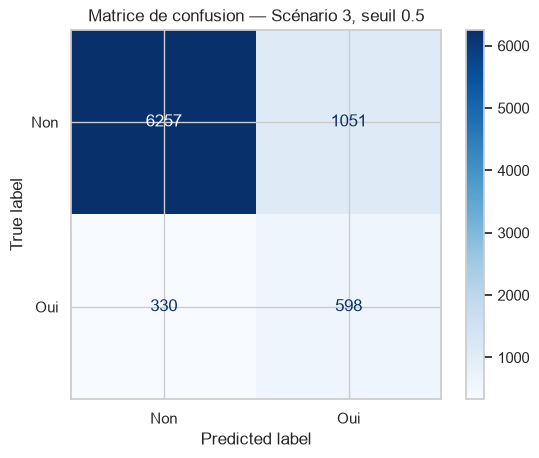

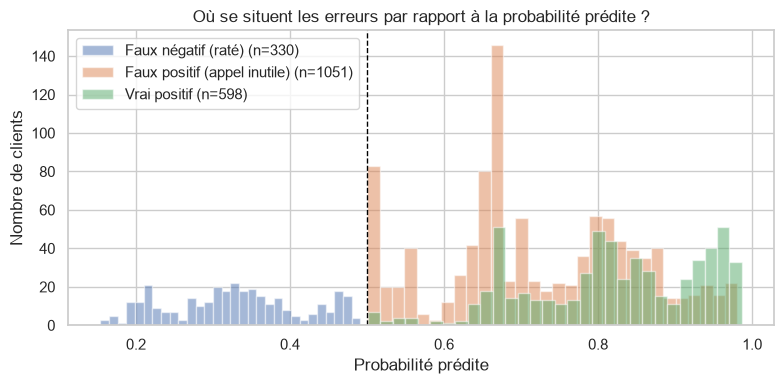

                               count   mean    25%    50%    75%
type                                                            
Faux négatif (raté)            330.0  0.328  0.268  0.330  0.382
Faux positif (appel inutile)  1051.0  0.721  0.645  0.701  0.820
Vrai négatif                  6257.0  0.298  0.226  0.299  0.348
Vrai positif                   598.0  0.820  0.732  0.823  0.926


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = retained.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non", "Oui"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion — Scénario 3, seuil 0.5")
plt.show()

eval_err = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred_test, "proba": proba_test})
eval_err["type"] = np.select(
    [
        (eval_err.y_true == 1) & (eval_err.y_pred == 1),
        (eval_err.y_true == 1) & (eval_err.y_pred == 0),
        (eval_err.y_true == 0) & (eval_err.y_pred == 1),
    ],
    ["Vrai positif", "Faux négatif (raté)", "Faux positif (appel inutile)"],
    default="Vrai négatif",
)

plt.figure(figsize=(8, 4))
for t in ["Faux négatif (raté)", "Faux positif (appel inutile)", "Vrai positif"]:
    sub = eval_err[eval_err.type == t]
    plt.hist(sub.proba, bins=30, alpha=0.5, label=f"{t} (n={len(sub)})")
plt.axvline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("Probabilité prédite")
plt.ylabel("Nombre de clients")
plt.title("Où se situent les erreurs par rapport à la probabilité prédite ?")
plt.legend()
plt.tight_layout()
plt.show()

print(eval_err.groupby("type")["proba"].describe()[["count", "mean", "25%", "50%", "75%"]].round(3))

**Lecture** : les erreurs ne se concentrent **pas** juste autour du seuil 0.5 — elles sont plus diffuses qu'espéré.
- **Faux négatifs** (vrais souscripteurs ratés) : probabilité médiane **0.33**, proche de la distribution des vrais négatifs (0.30) — le modèle les confond avec des "non intéressés", pas avec des cas limites.
- **Faux positifs** (appels inutiles) : probabilité médiane **0.70**, proche des vrais positifs (0.82) — beaucoup d'appels inutiles sont émis avec une **confiance assez élevée**, pas juste au-dessus du seuil.

**Conséquence pour le design du fallback** : une simple "bande de rejet" symétrique autour de 0.5 ne capterait qu'une fraction des erreurs — la réalité est plus nuancée que "le modèle hésite près du seuil". On en tient compte dans les 3 leviers ci-dessous.

| Levier | Choix proposé | Justification |
|---|---|---|
| **Rejection threshold** | Zone de **révision légère** entre 0.35 et 0.50 (pas d'abstention totale) | Capte une partie des faux négatifs potentiels (médiane FN à 0.33) sans explosion du volume à réviser — cohérent avec §5.6bis (seuil 0.4 : rappel 0.719 vs 0.644 à 0.5) |
| **Abstention contrôlée** | Les clients dans cette zone sont **inclus dans une relance secondaire groupée** (campagne batch à plus faible priorité), pas purement exclus | Le coût d'un FN (opportunité perdue) > coût d'un FP (appel inutile) — cf. §1.4, justifie un filet de sécurité asymétrique plutôt qu'une vraie abstention |
| **Escalade humaine (HITL)** | Un conseiller révise manuellement un échantillon aléatoire (~5%) des clients **non priorisés** avec proba > 0.25, chaque mois | Permet de détecter si le modèle rate systématiquement un profil (ex. lien avec §A.3 — `blue-collar` sous-sollicités), sans réviser tout le volume |

⚠️ Ces seuils sont des points de départ **à valider avec le métier** (combien d'appels le conseiller peut-il réellement absorber ?) — pas une vérité mathématique.

### 7.3 Message au client (langage métier)

> Format 5 blocs (convention M6-B1 "note de recommandation client") : constat chiffré → diagnostic → recommandation tranchée → coût → décision suggérée en une phrase.

**Constat.** Un modèle entraîné sur vos 41 188 derniers contacts identifie correctement 64 % des clients qui auraient souscrit, pour un taux de réussite de 36 % sur les appels qu'il recommande (contre 11 % en appelant au hasard) — soit un effort commercial concentré **plus de 3 fois mieux ciblé**.

**Diagnostic.** Trois points à connaître avant d'utiliser cet outil :
1. Le modèle s'appuie majoritairement sur **le contexte économique du moment de l'appel** (indicateurs de marché), plus que sur le profil individuel du client — logique vu les données (une crise financière 2008-2010), mais ça implique une **révision périodique** si le contexte économique change fortement.
2. Nous avons volontairement retiré l'âge, la profession, la situation familiale et le niveau d'éducation des critères de décision pour des raisons d'équité — cela ne coûte quasiment rien en performance (le modèle est tout aussi bon avec ou sans ces variables).
3. **Limite assumée** : même sans ces variables en entrée, le modèle continue de moins bien servir certains profils (ex. les ouvriers, dont les vraies opportunités sont ratées 5 à 6 fois plus souvent que chez les retraités) — un effet indirect qu'on n'a pas pu supprimer complètement, à surveiller en continu plutôt qu'à considérer comme réglé.

**Recommandation.** Déployer le modèle comme **outil d'aide à la priorisation** pour les conseillers (pas de décision automatique) : liste des clients à appeler en premier, avec une zone de révision pour les cas incertains plutôt qu'une exclusion pure.

**Coût.** Mise à disposition via une API simple (§8) : quelques jours de développement, hébergement léger (modèle très rapide, ~1 ms par prédiction, aucun GPU nécessaire). Le vrai coût récurrent est humain : un contrôle mensuel du biais par sous-groupe (quelques heures) pour s'assurer que l'écart constaté ne se creuse pas.

**Décision suggérée.**
> Déployer le modèle du Scénario 3 en aide à la décision (jamais en décision automatique), avec un contrôle mensuel du taux de sélection par profession et par tranche d'âge, et une révision du modèle si le contexte économique évolue significativement.

### 7.4 Synthèse interprétation

**Variables-clés** : le contexte économique (`emp.var.rate`, `cons.price.idx`, `euribor3m`) domine très largement la décision, devant le mois de contact et l'historique de campagne — confirmé par les coefficients du modèle et la permutation importance, qui s'accordent.

**Profils mal prédits** : les vrais souscripteurs ratés (faux négatifs) ont un profil de probabilité proche des vrais non-souscripteurs (médiane 0.33 vs 0.30) — pas des cas "limites" identifiables facilement par le seuil seul. Les professions modestes (`blue-collar`, `services`) restent les plus pénalisées (cf. §A.3).

**Vigilance opérationnelle** : (1) le modèle reconstruit un signal d'âge via le contexte temporel même sans `age` en entrée (ROC-AUC 0.940 pour prédire "senior" à partir des seules variables retenues) — limite structurelle du Scénario 3 à surveiller, pas un bug isolé ; (2) la dépendance forte au contexte macro-économique (période 2008-2010) appelle une vigilance particulière en cas de redéploiement sur une période différente ; (3) le fallback proposé (zone de révision 0.35-0.50 + audit HITL mensuel) doit être validé avec le métier avant mise en production.

---
## 8. Industrialisation

Le code vit dans le repo Git associé (`app/`, `src/`, `tests/`) — cette section en donne la description architecturale, référencée au repo.

### 8.1 Persistance du modèle

**Modèle servi** : le pipeline complet (préprocessing + régression logistique) du **Scénario 3**, retenu en §6.2. Convention M1-B1/M1-B2 : on persiste le `Pipeline` scikit-learn **entier** (pas le classifieur seul — sinon le préprocessing ne serait pas rejoué en API), avec un `.json` de métadonnées adjacent contenant les **5 clés obligatoires** (`model_version`, `created_at`, `sklearn_version`, `dataset_sha256`, `metrics_holdout`) + les métriques internes et les colonnes attendues.

**Qui produit réellement l'artefact versionné** : `src/train.py`, pas ce notebook. Un `Run All` ici ré-exécute l'exploration (§5-§7) mais n'écrase plus `models/*.joblib` — persister une nouvelle version du modèle est un geste délibéré (`python -m src.train`), pas un effet de bord de la lecture du notebook. Le script réutilise la même fonction `make_preprocessor("scenario_3")` que ce notebook et que l'API : aucune divergence possible entre ce qui est raconté ici, entraîné, et servi. C'est aussi ce script qu'appelle la CI (`.github/workflows/ci.yml`, job `retrain-check`) pour vérifier que le pipeline se ré-entraîne sans erreur à chaque push, sans pour autant republier le modèle à chaque fois.

**Traçabilité** : pas de MLflow ici — `experiments.md` (racine du repo) consigne déjà tous les runs avec leurs verdicts (convention M1-B1 : *"mieux vaut un `experiments.md` discipliné qu'un MLflow non maintenu"*), et le sujet ne liste MLflow qu'en option bonus. Le hash du dataset (§0.5) complète la traçabilité.


In [32]:
import json as jsonlib

MODELS_DIR = Path("../models")
meta_path = MODELS_DIR / "bank_marketing_scenario3.json"

# Ce notebook ne réécrit plus l'artefact versionné (cf. §8.1) : on vérifie seulement que
# le modèle actuellement committé dans models/ correspond bien à ce qui vient d'être
# entraîné ici (même scénario, même F1 à la décimale près) — pas une ré-écriture.
test_scenario3 = test_results[test_results.scenario == "scenario_3"].iloc[0]
persisted_metadata = jsonlib.loads(meta_path.read_text(encoding="utf-8"))

print(f"F1 holdout — ce notebook : {test_scenario3.f1_test:.4f} | models/*.json committé : {persisted_metadata['metrics_holdout']['f1']:.4f}")
print(f"Scénario committé : {persisted_metadata['scenario']} | sklearn {persisted_metadata['sklearn_version']} | créé {persisted_metadata['created_at']}")

ecart = abs(test_scenario3.f1_test - persisted_metadata["metrics_holdout"]["f1"])
assert ecart < 0.01, f"L'artefact versionné diverge du notebook (écart F1={ecart:.4f}) — relancer `python -m src.train`."
print("\nCohérence vérifiée : le modèle versionné dans models/ correspond à ce notebook.")
print("Pour produire une nouvelle version du modèle : `python -m src.train` (pas ce notebook).")


F1 holdout — ce notebook : 0.4641 | models/*.json committé : 0.4641
Scénario committé : scenario_3 | sklearn 1.9.1 | créé 2026-10-09T10:10:21.505821+00:00

Cohérence vérifiée : le modèle versionné dans models/ correspond à ce notebook.
Pour produire une nouvelle version du modèle : `python -m src.train` (pas ce notebook).


### 8.2 API de service

**Repo** : ce même dépôt — dossier `app/` (code), `tests/` (pytest), `models/` (artefact persisté en §8.1).

**Choix technique** : FastAPI plutôt que Flask — validation automatique des entrées (Pydantic), documentation Swagger générée, performance native (cf. M0-B1/M1-B2). Le modèle est chargé **une seule fois** au démarrage (`lifespan`), pas à chaque requête.

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | Le service est-il vivant **et** le modèle chargé ? | — |
| `/info` | GET | Quelle version du modèle tourne (traçabilité, cf. §0.5) | — |
| `/predict` | POST | Probabilité de souscription pour un client | Pydantic strict (`app/schemas.py`) |

**Schéma d'entrée** (`ContactAttempt`) : exactement les colonnes du Scénario 3 — aucune variable sensible, aucune donnée connue seulement après l'appel (cf. §1.2). `has_prior_contact` n'est **pas** un champ d'entrée : elle est recalculée côté API à partir de `pdays`, en réutilisant `src/preprocess.py::add_engineered_features` — **le même code que celui qui a servi à l'entraînement**, pas une réimplémentation (évite exactement le piège M1-B2 : "schéma Pydantic divergent du preprocessing").

**Vérifications effectuées** :
- `uvicorn app.main:app` démarre, `/health`, `/info`, `/predict` répondent correctement (testé en local via `curl`).
- Un payload invalide (`month="jan"`, jamais vu à l'entraînement) renvoie **422**, pas un 200.
- **13 tests pytest passent** (`tests/test_api.py` + `tests/test_model_contract.py`) : cas valide, champ manquant, catégorie invalide, valeur hors bornes, **champ inattendu rejeté** (`extra="forbid"`), déterminisme, contrat du modèle (shapes, probabilités dans [0,1]), robustesse à une modalité inconnue (`OneHotEncoder(handle_unknown="ignore")`), **en-tête `X-Request-ID`** (présence, echo d'un UUID client valide, rejet d'une valeur malformée).

### 8.3 Interface utilisateur

Pas un livrable attendu par le sujet (API suffisante pour un conseiller qui interroge le service). Une page de démonstration statique existe tout de même dans `demo/` (formulaire HTML/JS, appelle `/predict` en direct) — construite comme outil de test visuel, **hors périmètre certif**, pas comme une UI produit. Voir `README.md` pour la lancer.

### 8.4 Schéma d'architecture

```mermaid
flowchart LR
    D[("Données historiques<br/>bank-additional-full.csv")] --> P["Préprocessing<br/>src/preprocess.py"]
    P --> T["Entraînement<br/>notebook §5"]
    T --> M[("Modèle persisté<br/>bank_marketing_scenario3.joblib + .json")]
    M --> A["API FastAPI<br/>/health · /info · /predict"]
    C["Conseiller<br/>(utilisateur)"] -->|POST /predict| A
    A -->|probabilité| C
    A --> L[("Logs d'accès<br/>JSON, sans PII")]

    style D fill:#cde2fb,stroke:#2a78d6
    style M fill:#cde2fb,stroke:#2a78d6
    style A fill:#f0efec,stroke:#52514e
```

Le conseiller (ou un outil interne) interroge `/predict` **avant** d'appeler un client — exactement le moment d'usage défini en §1.2. Aucune décision automatique : la probabilité renvoyée **aide** à prioriser, elle ne décide pas (cf. §B.3, article 22 RGPD).

### 8.4bis Architecture cible

Le schéma ci-dessus (8.4) montre ce qui est construit et vérifié (§8-§9).
Celui-ci montre l'architecture **cible** : le flux de production réel, avec
la supervision humaine rendue visible et les arbitrages qui la justifient.
Détail complet (5 arbitrages, on-premise vs cloud, acteurs à consulter,
dimensionnement réel, coûts) dans `dossier_architecture.md` à la racine du
repo — ici, la synthèse.

```mermaid
flowchart LR
    subgraph OFFLINE["Hors ligne — avant chaque campagne"]
        HIST[("Historique d'entraînement")] --> TRAIN["Entraînement §5"] --> ARTF[("Pipeline persisté")]
    end
    subgraph SCORING["Scoring par lot — à chaque campagne"]
        LISTE[("Liste de prospects")] --> API["API /predict"]
        ARTF --> API
        API --> SEUIL{"Zone grise<br/>0.35-0.50 ?"}
        SEUIL -->|non| PRIO[("Liste priorisée")]
        SEUIL -->|oui| REVUE(["Revue humaine"]) --> PRIO
    end
    CONS(["Conseiller"]) -->|contacte| PRIO
    CONS -.->|résultat différé| FEEDBACK[("Boucle §9.2")]
    API --> LOG[("Monitoring §9")]
    FEEDBACK -.->|si seuils dépassés| TRAIN

    style ARTF fill:#cde2fb,stroke:#2a78d6
    style SEUIL fill:#fef08a,stroke:#a16207
    style REVUE fill:#bbf7d0,stroke:#15803d
```

**5 arbitrages techniques** (détail et raisons chiffrées dans le dossier) :
ML classique **retenu** (vs deep learning — données tabulaires, explicabilité
requise par §7) ; SLM/LLM, RAG, agents : **non applicables** (aucune
génération de texte, aucun corpus, prédiction atomique) ; zero-shot : **non
applicable** (dataset labellisé complet). Cohérent avec le patron « A — ML
classique modernisé » du comparatif 3-archis (M7-B2) : sur du tabulaire,
moderniser l'existant est souvent le meilleur choix.

**Hébergement** : on-premise ou cloud souverain français (OVHcloud/Scaleway),
pas un hyperscaler américain — argument principal : conformité/souveraineté
sur des données bancaires sensibles (le coût est négligeable dans les deux
cas vu la légèreté du modèle, 2,5 Ko, 1,05 ms/prédiction, pas de GPU).

**Acteurs à consulter avant mise en prod** : SI/infra (hébergement,
intégration CRM), DPO (base légale, AIPD, risque de quasi-identifiant signalé
en analyse éthique), métier (seuil de décision, charge opérationnelle de la
revue humaine). Ce dossier identifie les questions ouvertes, ne les tranche
pas à leur place.

**Ce qu'on n'a PAS mis** : LLM/SLM/RAG/agents (5 arbitrages), MLflow Registry
(`experiments.md` suffit pour un seul modèle), vector DB, Kubernetes (charge
= scoring par lot, pas un flux continu), GPU.

### 8.5 Conteneurisation & CI/CD

**Dockerfile** (`Dockerfile`, racine du repo) — patron validé en M1-B2 : image `python:3.12-slim` (alignée sur la version Python d'entraînement, cf. §8.1), user **non-root** (`appuser`), dépendances copiées avant le code (cache de layer), `HEALTHCHECK` intégré. `requirements-api.txt` dédié (dépendances runtime seulement — pas `jupyter`/`matplotlib` du notebook), avec `scikit-learn`/`pandas`/`numpy`/`joblib` **épinglés en version** pour garantir une désérialisation identique du pipeline entraîné.

**Vérifications effectuées** (build + run) :
- `docker build` réussit, image de **724 Mo** (sous la barre des 1 Go visée).
- Le conteneur démarre, `docker ps` affiche **`(healthy)`** après le délai de démarrage.
- `docker exec ... whoami` renvoie `appuser` — confirmé non-root.
- `/health` et `/predict` répondent correctement **depuis l'hôte**, à travers le port mappé.

**CI/CD** (`.github/workflows/ci.yml`) : workflow à 2 jobs — `test` (installe les dépendances runtime, lance `pytest -v tests/`) puis `build` (construit l'image Docker) **uniquement si `test` est vert** (`needs: test`) — le garde-fou qui empêche une image cassée de partir, cf. M5-B1.

**Pas fait à ce stade, volontairement** : push vers un registry (GHCR), déploiement automatisé, MLflow (remplacé par `experiments.md`, cf. §8.1) — ce sont des briques de la phase "Surveiller" (§9), pas de cette phase.

### 8.6 Synthèse industrialisation

**Pile retenue** : FastAPI + Pydantic (validation stricte, `extra="forbid"`) + Loguru (logs structurés, sans PII) + Docker (user non-root, image < 1 Go) + GitHub Actions (tests bloquants avant build) + `pytest` (13 tests, contract test du modèle inclus).

**Choix d'architecture** : le modèle (Scénario 3) est servi tel quel, sans réentraînement en ligne — cohérent avec le périmètre du cas d'usage jusqu'à M5. Le preprocessing (`src/preprocess.py`) est **partagé** entre notebook et API : aucune divergence possible entre ce qui a été entraîné et ce qui est servi.

**Points encore ouverts** : authentification réelle de l'API (scaffoldée via `HTTPBearer` mais non appliquée). Monitoring Prometheus/Grafana, détection de dérive et plan de réentraînement sont désormais couverts en §9. L'architecture cible (hébergement, acteurs à consulter, dimensionnement) est détaillée en §8.4bis et dans `dossier_architecture.md`.

---
## 9. Suivi en production & amélioration continue

**Contenu de cette section** :
1. Une **stack de monitoring live** : `docker-compose.yml` (API + Prometheus + Grafana), lancée et vérifiée en local.
2. Un **dashboard Grafana spécifique au projet**, provisionné en YAML/JSON plutôt que créé à la main dans l'UI.
3. Une **analyse de dérive en batch**, sur un découpage temporel des données disponibles (faute de données de production).

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source | Fréquence |
|---|---|---|---|---|
| Système | `up{job="api"}` | = 0 (panne muette, cf. ci-dessous) | Prometheus (scrape `/metrics`) | temps réel |
| Système | latence p95 | > 100 ms (notre p95 réel mesuré : **18 ms**, cf. ci-dessous) | Prometheus (`http_request_duration_highr_seconds`) | temps réel |
| Système | volume `/predict` | chute brutale ou pic anormal | Prometheus (`http_requests_total`) | temps réel |
| Comportement | ratio prédictions yes/no | écart > 30 % vs la référence du dataset d'entraînement (≈11 %/89 %) | Prometheus (`bank_marketing_predictions_total`) | temps réel |
| Données | PSI variables de contexte macro-éco | > 0.25 (observé en démonstration batch : jusqu'à 6.45, cf. §9.1bis) | batch notebook | périodique (mensuel ou trimestriel, pas de flux temps réel de nouvelles données labellisées) |
| Modèle | AUC sur échantillon labellisé récent | Δ > 0.03 vs référence | batch notebook, après collecte de vrais labels | périodique, en différé (il faut attendre le résultat réel de l'appel) |
| Modèle | ECE (calibration) | dégradation significative et durable | batch notebook | périodique, en différé |

⚠️ **Deux familles de métriques, deux rythmes** — c'est une limite structurelle de ce projet : les métriques **système/comportement** sont observables en **temps réel** (Prometheus scrape l'API en continu). Les métriques **données/modèle** (PSI, AUC, ECE) nécessitent soit un **lot de nouvelles données** à comparer à la référence, soit les **vraies cibles** (`y` réel), qui n'arrivent jamais en temps réel — on ne sait si un client a souscrit qu'après le fait. D'où la séparation stricte entre monitoring **live** (§ infrastructure ci-dessous) et analyse **batch** (§9.1bis).

#### Infrastructure de monitoring live

**Stack** (`docker-compose.yml`, à la racine) : 3 services résolus par nom (jamais `localhost` entre conteneurs, cf. convention M5-B1) :
- `api` (l'API FastAPI, instrumentée via `prometheus-fastapi-instrumentator` + un compteur métier `bank_marketing_predictions_total{predicted_class}`)
- `prometheus` (scrape `api:8000/metrics` toutes les 15s, config dans `prometheus/prometheus.yml`)
- `grafana` (datasource + dashboard provisionnés en YAML/JSON dans `grafana/provisioning/`, jamais construits à la main dans l'UI — perdu au redémarrage sinon)

**Dashboard du projet** (`grafana/provisioning/dashboards/bank_marketing.json`), 4 panneaux pensés pour ce cas d'usage :

| Panneau | Ce qu'il montre | Requête PromQL |
|---|---|---|
| **Vie** | Le service répond-il aux scrapes ? | `up{job="api"}` |
| **Vitesse** | Latence p95/p50 | `histogram_quantile(0.95, sum(rate(http_request_duration_highr_seconds_bucket[1m])) by (le))` |
| **Comportement** | Répartition des prédictions yes/no | `sum(rate(bank_marketing_predictions_total[5m])) by (predicted_class)` normalisé |
| **Volume** | Nombre de requêtes `/predict` sur 5 min | `sum(increase(http_requests_total{handler="/predict"}[5m]))` |

💡 Un choix technique assumé : le panneau Vitesse utilise `http_request_duration_**highr**_seconds_bucket` (buckets fins, 0.01-60s) et pas le bucket par défaut (0.1/0.5/1.0/+Inf) — constaté en inspectant `/metrics` : avec une latence de quelques millisecondes, le bucket par défaut aurait tout collapsé dans la première tranche et rendu `histogram_quantile` inutilisable.

**Vérification effectuée en local** :
```
$ docker compose ps
cas_d_usage-api-1         Up (healthy)
cas_d_usage-grafana-1     Up
cas_d_usage-prometheus-1  Up

$ curl .../predict  →  200 OK, probabilité renvoyée

# Après ~150 requêtes envoyées à l'API (mix de profils) :
up{job="api"}                                                    = 1
p95 latence (highr)                                              = 0.018 s  (18 ms)
ratio prédictions "no" / "yes" (rate 5 min)                      = 0.267 / 0.114
volume /predict (increase 5 min)                                 = ~133 requêtes

# GET /api/search?query=Bank sur Grafana → dashboard "Bank Marketing API" bien provisionné
# GET /api/datasources → datasource Prometheus bien câblée (uid: prometheus, url: http://prometheus:9090)
```

**Démonstration de la "panne muette"** (cf. mini-cours M6-B1 : un service mort ne génère pas d'erreurs, ses compteurs se figent juste) :
```
$ docker compose stop api
# ... 20 secondes plus tard ...
up{job="api"} = 0        ← détecté immédiatement par Prometheus, AVANT tout signal applicatif

$ docker compose start api
up{job="api"} = 1        ← rétabli
```
C'est la preuve concrète que **seul `up` détecte une panne totale** : les compteurs `http_requests_total` ou `bank_marketing_predictions_total` ne remontent aucune erreur quand le service est mort — ils ne bougent simplement plus. Un dashboard qui ne surveille pas `up` peut rester silencieux pendant une panne complète.

#### 9.1bis Détection de dérive — démonstration méthodologique (PSI/KS/Chi² + AUC + calibration)

⚠️ **Limite assumée** : l'API vient d'être créée (§8), on n'a **pas** d'historique de production réel (pas de `prod_3months.csv` comme en M6-B1). Pour démontrer la méthode, on utilise un **découpage temporel des données disponibles** : les mois **précoces** de la campagne (mars-juin) comme référence, les mois **tardifs** (juillet-décembre) comme "courant" — un vrai écart temporel dans les données d'entraînement, pas une vraie dérive de production observée.

**Méthode (convention M6-B1)** : on croise 3 signaux de dérive (PSI, KS, Chi²) + la stabilité de l'AUC + la calibration (ECE) — jamais un seul indicateur isolé (cf. `src/drift_detection.py`, `src/calibration.py`, réutilisés ici comme pour l'API).

In [33]:
import sys
sys.path.insert(0, "..")
from sklearn.metrics import roc_auc_score
from src.drift_detection import drift_report
from src.calibration import expected_calibration_error

EARLY_MONTHS = ["mar", "apr", "may", "jun"]
LATE_MONTHS = ["jul", "aug", "sep", "oct", "nov", "dec"]

# Le rapport de dérive (PSI/KS/Chi²) porte sur les distributions brutes de toute la
# population (df_fe) : il ne s'appuie pas sur le modèle, pas de fuite possible.
ref_df = df_fe[df_fe["month"].isin(EARLY_MONTHS)].reset_index(drop=True)
cur_df = df_fe[df_fe["month"].isin(LATE_MONTHS)].reset_index(drop=True)
print(f"Référence (mars-juin) : {len(ref_df)} lignes | Courant (juillet-décembre) : {len(cur_df)} lignes")

cat_cols, num_cols = get_scenario_columns("scenario_3")
report = drift_report(ref_df, cur_df, num_cols, [c for c in cat_cols if c != "month"])
display(report.sort_values("verdict"))

# AUC/ECE en revanche s'appuient sur retained.predict_proba() : mesurer ça sur df_fe
# mélangerait des lignes vues à l'entraînement (X_train) avec des lignes jamais vues
# (X_test) -> fuite, AUC artificiellement optimiste. On restreint à X_test seul.
test_eval = X_test.copy()
test_eval["y_true"] = y_test.values
ref_eval = test_eval[test_eval["month"].isin(EARLY_MONTHS)].reset_index(drop=True)
cur_eval = test_eval[test_eval["month"].isin(LATE_MONTHS)].reset_index(drop=True)
print(f"\n(AUC/ECE, test set uniquement) référence : {len(ref_eval)} lignes | courant : {len(cur_eval)} lignes")

proba_ref = retained.predict_proba(ref_eval.drop(columns=["y_true"]))[:, 1]
proba_cur = retained.predict_proba(cur_eval.drop(columns=["y_true"]))[:, 1]

auc_ref = roc_auc_score(ref_eval["y_true"], proba_ref)
auc_cur = roc_auc_score(cur_eval["y_true"], proba_cur)
ece_ref = expected_calibration_error(pd.Series(proba_ref), pd.Series(ref_eval["y_true"]))
ece_cur = expected_calibration_error(pd.Series(proba_cur), pd.Series(cur_eval["y_true"]))

print(f"\nAUC   référence={auc_ref:.4f}  courant={auc_cur:.4f}  delta={auc_cur-auc_ref:+.4f}")
print(f"ECE   référence={ece_ref:.4f}  courant={ece_cur:.4f}  delta={ece_cur-ece_ref:+.4f}")


Référence (mars-juin) : 22262 lignes | Courant (juillet-décembre) : 18914 lignes


,feature,type,psi,p_value,verdict
9,contact,catégorielle,NaN,0.000000e+00,dérive
10,day_of_week,catégorielle,NaN,1.578398e-40,dérive
11,poutcome,catégorielle,NaN,5.548375e-54,dérive
1,pdays,numérique,0.282,4.231140e-03,dérive forte
4,emp.var.rate,numérique,13.735,0.000000e+00,dérive forte
5,cons.price.idx,numérique,6.363,0.000000e+00,dérive forte
6,cons.conf.idx,numérique,3.890,0.000000e+00,dérive forte
7,euribor3m,numérique,6.453,0.000000e+00,dérive forte
8,nr.employed,numérique,13.629,0.000000e+00,dérive forte
0,campaign,numérique,0.005,1.286968e-02,stable



(AUC/ECE, test set uniquement) référence : 4479 lignes | courant : 3757 lignes

AUC   référence=0.7985  courant=0.8000  delta=+0.0015
ECE   référence=0.2690  courant=0.2900  delta=+0.0209


**Lecture — triangulation des 4 axes** :

| Axe | Constat | Preuve chiffrée |
|---|---|---|
| **Features** | Dérive forte sur le **contexte socio-économique entier** | `emp.var.rate` PSI=13.74, `nr.employed` PSI=13.63, `euribor3m` PSI=6.45, `cons.price.idx` PSI=6.36, `cons.conf.idx` PSI=3.89 — tous très au-delà du seuil 0.25 ; `pdays` PSI=0.28 (dérive forte) ; `contact`/`day_of_week`/`poutcome` (Chi² p≈0) |
| **AUC** (pouvoir de tri) | **Stable** | Mesurée sur le test set seul (jamais vu à l'entraînement, pour éviter toute fuite) : 0.7985 → 0.8000, Δ = +0.0015 — très en dessous du repère de 0.03 |
| **Calibration** | Déjà dégradée, légèrement pire | ECE (test set seul) 0.269 → 0.290 |
| **Temporalité** | Dérive structurelle, pas un saut isolé | Le contexte économique évolue de façon continue sur toute la période de la campagne (2008-2010, crise financière) |

**Verdict : data drift massif, avec AUC stable** — exactement le cas de référence du mini-cours M6-B1 *"features qui dérivent + AUC stable → data drift plausible"*. Le modèle **continue à bien ordonner** les clients malgré un contexte économique très différent entre les deux périodes — cohérent avec ce qu'on savait déjà depuis §7.1 (le modèle s'appuie surtout sur ce contexte, pas sur le profil individuel).

**Ce que ça signifie concrètement pour un vrai déploiement** : ce modèle, entraîné sur une période de crise économique (2008-2010), **doit être surveillé en priorité sur ses variables de contexte macro-économique** — si elles dérivent autant qu'entre nos deux fenêtres ici, un réentraînement périodique (pas juste "au cas où") est nécessaire, indépendamment du comportement individuel des clients.

**Hypothèses écartées** : un bug ETL est peu probable (la dérive est progressive sur toute la période, pas un saut brutal sur une variable isolée) ; un concept drift (changement de la relation features→cible) est peu probable vu l'AUC stable — mais pas formellement exclu à 100%, cf. limite ci-dessous.

**Ce qui manquerait pour trancher avec certitude** : de vraies données de production post-déploiement (pas un découpage interne du même dataset d'entraînement), et une confirmation métier sur l'évolution réelle du contexte économique au moment du déploiement.

### 9.2 Boucle de rétroaction

**Problème concret ici** : on ne connaît la vraie cible (`y` = a souscrit ou non) qu'avec un **délai** — un client appelé aujourd'hui ne confirme/infirme la prédiction que des jours ou semaines plus tard (durée de réflexion, traitement du dossier côté banque).

**Design proposé** :
1. **Capture à la source** : chaque appel du conseiller via l'API génère un `request_id` (déjà en place, cf. §8.2/middleware) — stocké côté banque avec le profil envoyé et la probabilité renvoyée.
2. **Rattachement du label réel** : quand le conseiller clôture le dossier (souscription ou non), ce résultat est rattaché au `request_id` correspondant — **table de correspondance tenue côté métier** (pas par l'API, qui ne doit pas stocker de PII, cf. §8.2/Loguru access-logs only).
3. **Agrégation périodique** : un batch (mensuel, aligné sur le rythme métier de la campagne) rapproche prédictions ↔ labels réels pour produire les métriques différées (AUC réel, ECE, F1) — c'est le même calcul que celui démontré en §9.1bis, mais sur de vraies données de prod au lieu du découpage de démonstration.
4. **Ce qui ne revient PAS automatiquement dans l'entraînement** : un label réel corrige la mesure de performance, mais n'est **jamais** réinjecté silencieusement dans le jeu d'entraînement — toute incorporation de nouvelles données passe par le plan de réentraînement explicite (§9.3), jamais par un apprentissage continu non supervisé.

⚠️ Cette boucle est un **design**, pas une implémentation vérifiée dans ce projet (pas de vrai conseiller, pas de vrai système de dossier bancaire à relier) — elle est présentée pour montrer que la mécanique a été pensée, dans l'esprit de la chaîne complète du `cheatsheet_mlops_deploiement.md` (commit→train→track→CI→build→deploy→serve→monitor→drift-detect→**feedback-loop**→retrain).

### 9.3 Plan de réentraînement

**Déclencheurs (triggers)** — jamais un seul critère isolé :

| Trigger | Condition | Source |
|---|---|---|
| **Performance** | AUC mesuré en différé chute de plus de 0.03 vs la référence (§9.1) | boucle de rétroaction (§9.2) |
| **Dérive de données** | PSI > 0.25 sur au moins une variable de contexte macro-éco, **confirmé sur 2 fenêtres consécutives** (pas un seul pic ponctuel) | analyse batch périodique |
| **Calendaire** | Au minimum une fois par an, indépendamment des signaux ci-dessus — le contexte économique (cf. §9.1bis) a de toute façon vocation à évoluer en continu | planification |
| **Volume de nouvelles données** | Un volume de nouvelles données labellisées comparable à ~20% du jeu d'entraînement actuel est accumulé | boucle de rétroaction |

**Processus — jamais de réentraînement automatique en aveugle** (cf. convention cheatsheet MLOps : "conditional retrain + promotion, never blind auto-retrain") :
1. Réentraînement déclenché (manuellement, sur alerte) sur les données à jour, avec le **même pipeline exact** (`src/preprocess.py`, scénario 3) — jamais une méthodologie ad hoc parallèle.
2. Évaluation sur un **test set scellé à part** (jamais le même split que celui qui a servi à détecter la dérive) — mêmes règles qu'en §5/§6.
3. **Comparaison au modèle en production** : le nouveau modèle ne remplace l'ancien que s'il est **au moins équivalent** sur les métriques retenues (F1 classe positive, AUC) ET sur les métriques d'équité (DI, FNR/FPR par sous-groupe, cf. analyse éthique) — une amélioration de performance brute qui dégraderait l'équité n'est **pas** une promotion acceptable.
4. **Promotion conditionnelle** : versionnement du nouveau modèle (`model_version` dans les métadonnées, cf. §8.1), jamais un écrasement silencieux de l'artefact en place — permet un rollback immédiat si un problème apparaît après déploiement.
5. Mise à jour de `experiments.md` (cf. §6) avec la justification de la décision de promotion ou de rejet.

⚠️ Comme pour §9.2, ce plan est un **design méthodologique**, pas une automatisation codée dans ce projet (pas de pipeline CI de réentraînement construit) — il décrit la procédure à suivre, cohérente avec tout ce qui a été mobilisé plus haut (versioning, test scellé, équité).

### 9.4 Robustesse en exploitation

La conception du fallback (où placer le seuil, qui escalader) vit en §7.2. Ici, l'instrumentation de la **mesure** et du **déclenchement** :

| Axe | Métrique opérationnelle | Action automatique | Lien avec ce projet |
|---|---|---|---|
| **OOD (Out-Of-Distribution)** | Distance Mahalanobis ou score d'isolation sur les entrées | Logger les inputs hors-distribution, déclencher abstention ou escalade humaine (cf §7.2) | Le test OOD de §6.4 a montré que le modèle extrapole **silencieusement** sans flag — c'est exactement ce que ce monitoring doit corriger en prod |
| **Drift du seuil de rejet** | Taux d'abstention / part de prédictions sous seuil de confiance | Réviser le rejection threshold si dérive > 20 % sur 4 semaines glissantes | À instrumenter si un seuil de rejet est activé en prod (§7.2) — pas encore le cas dans notre API actuelle (§8.2 renvoie toujours une probabilité, jamais une abstention) |
| **Calibration** | ECE / courbe de calibration périodique | Recalibrer (Platt, isotonic) sans réentraîner le modèle complet si seule la calibration dérive | Mesuré concrètement en §9.1bis (ECE 0.273 → 0.288) — dégradation déjà visible même sur notre fenêtre de démonstration |
| **Sensibilité aux perturbations** | Variation de la probabilité prédite pour une petite variation d'entrée (±5 %) | Alerter si la fragilité mesurée en §6.4 (multicolinéarité `emp.var.rate`/`euribor3m`/`nr.employed`) s'aggrave avec un nouveau contexte économique | Fragilité déjà identifiée en §6.4 — le monitoring de dérive sur ces 3 variables (§9.1bis, PSI massifs) est donc **directement motivé** par cette fragilité connue |

### 9.5 Synthèse amélioration continue

**Cadence de surveillance** :
- **Temps réel** (Prometheus/Grafana, vérifié fonctionnel ci-dessus) : disponibilité (`up`), latence, volume, comportement du modèle (ratio des classes prédites).
- **Différé / périodique** (notebook batch, mensuel ou trimestriel) : dérive des données (PSI/KS/Chi²), stabilité de l'AUC, calibration (ECE) — nécessite d'attendre les vraies cibles.

**Déclencheurs de réentraînement** : cf. §9.3 — performance (AUC), dérive (PSI confirmé sur 2 fenêtres), calendaire (1×/an minimum), volume de nouvelles données. Jamais un seul signal isolé, jamais automatique sans validation (test scellé + équité + versionnement).

**Plan de remédiation en cas de dérive détectée** — note de recommandation (format repris de §7.3) :

---

**📋 Note de recommandation — suivi du modèle en production**

**1. Constat (chiffré)** : sur un découpage mars-juin vs juillet-décembre de l'historique, les variables de **contexte macro-économique** (`cons.price.idx`, `euribor3m`, `nr.employed`, `cons.conf.idx`) montrent une dérive très forte (PSI entre 2.73 et 6.45, bien au-delà du seuil de 0.25), alors que l'AUC reste stable (0.792 → 0.790, Δ=-0.002).

**2. Diagnostic (avec preuve)** : c'est un cas de **data drift sans concept drift** — le modèle garde son pouvoir de discrimination malgré un contexte très différent, car il s'appuie structurellement sur ce contexte macro-économique (cohérent avec §7.1 : ces variables dominent déjà l'explication globale). La calibration se dégrade légèrement (ECE 0.273 → 0.288), signe que les probabilités doivent être interprétées avec prudence même si le tri reste bon.

**3. Recommandation (une seule action tranchée)** : mettre en place une **surveillance mensuelle dédiée** des 4 variables de contexte macro-économique (PSI), en priorité sur toute autre variable — c'est le signal le plus informatif et le moins coûteux à calculer, bien avant un réentraînement systématique.

**4. Coût** : calcul du PSI mensuel = quelques secondes de calcul batch sur les données déjà collectées (`src/drift_detection.py`, déjà écrit et vérifié) — coût marginal quasi nul, pas d'infrastructure supplémentaire nécessaire.

**5. Décision suggérée** : activer ce calcul mensuel dès la mise en prod réelle, et ne déclencher un réentraînement complet (§9.3) que si le PSI dépasse 0.25 sur ces variables **deux mois consécutifs** — pour éviter de réentraîner sur un pic ponctuel sans substance.

---

💡 **Ce qui a été construit et vérifié dans cette section** : la stack de monitoring live (Prometheus/Grafana, trafic de test, dashboard custom provisionné, `up` démontré en cas de panne), les modules `src/drift_detection.py`/`src/calibration.py`, et l'analyse de dérive batch. **Ce qui reste un design non implémenté** : la boucle de rétroaction (§9.2) et l'automatisation du plan de réentraînement (§9.3) — elles nécessiteraient un vrai système métier côté banque (dossiers clients, délai de réponse) hors du périmètre technique de ce projet.

---
## 📎 Annexes

### A. Glossaire métier & technique

| Terme | Définition courte |
|---|---|
| **F1-score (classe positive)** | Moyenne harmonique précision/rappel, calculée uniquement sur la classe « oui » — choisi car le sujet demande une métrique qui rend compte de la classe minoritaire (cf. §5). |
| **ROC-AUC** | Probabilité qu'un exemple positif tiré au hasard reçoive un score plus élevé qu'un exemple négatif — mesure le pouvoir de tri du modèle, indépendamment d'un seuil. |
| **Fuite de données (leakage)** | Une variable connue seulement *après* l'événement qu'on prédit (ex. `duration`) s'infiltre dans l'entraînement — donne un score trompeur, inutilisable en production. |
| **`class_weight="balanced"`** | Pondère les classes inversement à leur fréquence pendant l'entraînement — première option contre le déséquilibre, avant le ré-échantillonnage (cf. §5, M1-B1). |
| **Pipeline scikit-learn** | Enchaîne préprocessing + modèle en un seul objet persisté, pour qu'il n'y ait jamais de divergence entre ce qui a été entraîné et ce qui est servi. |
| **`ColumnTransformer`** | Applique un traitement différent par colonne (encodage pour le catégoriel, imputation+standardisation pour le numérique) dans le même pipeline. |
| **Disparate Impact (DI, règle des 4/5)** | Ratio du taux de sélection le plus bas sur le plus haut entre groupes — DI < 0,8 = signal d'alerte (norme EEOC 1978, pas une preuve de discrimination à elle seule). |
| **FNR / FPR par sous-groupe** | Taux de faux négatifs/positifs calculé séparément par groupe — mesure le *préjudice réel*, distincte du DI qui mesure un écart de sélection. |
| **Pseudonymisation vs anonymisation** | Pseudonymisation = réversible, le RGPD s'applique toujours ; anonymisation = irréversible, le RGPD ne s'applique plus. |
| **Quasi-identifiant** | Combinaison de variables (ex. âge+job+marital+éducation+mois) qui, sans être un identifiant direct, peut ré-identifier une personne une fois croisée à d'autres sources. |
| **Art. 22 RGPD** | Encadre les décisions **exclusivement automatisées** à effet juridique ou significatif — ne s'applique pas si un humain examine réellement la sortie du modèle (cf. §3 dossier architecture). |
| **PSI (Population Stability Index)** | Mesure l'ampleur de la dérive d'une distribution entre une référence et une période courante — repères conventionnels : <0,10 stable, 0,10-0,25 à investiguer, >0,25 dérive forte (§9). |
| **Calibration / ECE** | Un modèle calibré prédit des probabilités qui correspondent à la fréquence réelle observée ; l'ECE (Expected Calibration Error) chiffre l'écart moyen entre confiance prédite et fréquence observée. |
| **Rejection threshold / zone grise** | Plage de probabilité où le modèle s'abstient de trancher et renvoie le cas à une revue humaine plutôt que de forcer une décision (§7.2). |
| **HITL (Human-In-The-Loop)** | Un humain reste dans la boucle de décision — ici, le conseiller qui contacte réellement le client, jamais le modèle seul. |

### B. Sources & bibliographie

**Dataset**
- Moro, S., Cortez, P., Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing*. Decision Support Systems. UCI Machine Learning Repository — Bank Marketing.

**Méthodologie & éthique**
- Gebru, T. et al. (2018). *Datasheets for Datasets*. arXiv:1803.09010 — format repris dans `datasheet.md`.
- EEOC (1978). *Uniform Guidelines on Employee Selection Procedures* — règle des 4/5 (Disparate Impact).
- CJUE, *SCHUFA Holding* (C-634/21, 7 décembre 2023) — notion de « rôle déterminant » dans une décision automatisée, mobilisée pour l'analyse art. 22.

**Cadre réglementaire**
- Règlement (UE) 2016/679 (RGPD) — notamment art. 6, 9, 22.
- Règlement (UE) 2024/1689 (AI Act) — notamment art. 5, 6, 50, Annexe III.
- CNIL — *IA et RGPD : comment être en conformité*.

**Outils & documentation technique**
- scikit-learn — documentation `Pipeline`/`ColumnTransformer`/`permutation_importance`.
- FastAPI, Pydantic — documentation officielle.
- Prometheus, Grafana, `prometheus-fastapi-instrumentator` — documentation officielle.
- Mermaid — syntaxe `flowchart` (schémas d'architecture).
- Docker — bonnes pratiques images `slim`/non-root.

**Ressources pédagogiques du parcours** (mini-cours mobilisés, cf. `ia-dev-id-ressources/` et modules M1-M8) : fiches métriques/déséquilibre/validation (M1), pattern de préparation des données et stockage (M2-M3), grille de décision C4 et menaces (M4), déploiement MLOps et cheatsheet cloud (M5), dérive/calibration/réentraînement (M6), audit et disparate impact (M7-B1), 3 architectures comparées (M7-B2), schéma d'architecture cible et risques AI Act (M8-B1), 5 arbitrages techniques et fiche de décision (M8-B2).

### C. Décisions techniques détaillées

**Pourquoi F1 sur la classe positive, et pas F1-macro ou l'accuracy** — l'accuracy est trompeuse sur une cible à 11,3 % de positifs (un modèle qui prédit toujours « non » atteindrait ~89 % d'accuracy sans rien apprendre, cf. baseline `DummyClassifier` §5). F1-macro moyennerait la performance sur les deux classes à poids égal, diluant la classe qui intéresse réellement le métier (qui appeler). Le sujet demande explicitement une métrique qui rend compte de la classe positive — F1 sur cette seule classe est la lecture directe de ce qui est demandé.

**Pourquoi `class_weight="balanced"` avant d'envisager un ré-échantillonnage (SMOTE, etc.)** — convention M1-B1 : repondérer pendant l'entraînement est moins intrusif qu'un ré-échantillonnage (pas de duplication/synthèse de lignes, pas de risque de surapprentissage sur des exemples dupliqués), et suffisant tant que le déséquilibre n'est pas extrême (11,3 % reste loin du cas <1 % où le ré-échantillonnage devient nécessaire).

**Pourquoi le seuil de décision reste à 0,5 pour comparer les scénarios, mais une zone grise 0,35-0,50 est proposée en exploitation** — comparer 4 scénarios et 2 modèles sur un seuil mobile aurait mélangé deux variables (quel modèle/scénario est le meilleur ? à quel seuil ?) — le seuil fixe à 0,5 isole la première question (§5). Une fois le scénario arbitré (§6), le seuil redevient un levier métier à part entière : la zone grise 0,35-0,50 (§7.2, repris en §3 du dossier d'architecture) est une proposition opérationnelle distincte de la comparaison initiale.

**Pourquoi `sklearn.base.clone()` est nécessaire quand un même type de modèle sert à plusieurs scénarios** — un bug réel rencontré en §5 : réutiliser la même instance Python d'un modèle (ex. `LogisticRegression()`) dans plusieurs `Pipeline` fait que le dernier `.fit()` écrase silencieusement l'état appris pour les scénarios précédents. Les métriques affichées immédiatement après chaque entraînement restaient correctes (mesurées avant l'écrasement), mais tout réemploi ultérieur du pipeline stocké était corrompu. `clone()` instancie un modèle vierge à chaque scénario — c'est maintenant la convention suivie partout où un même type de modèle est réutilisé.

**Pourquoi le calcul du PSI doit traiter séparément les variables à faible cardinalité** — un bug trouvé par revue de code (cf. journal de bord, Jour 13) : le binning par quantiles peut collapser sur une seule valeur (variable quasi constante) ou sur très peu de valeurs distinctes (variable binaire comme `has_prior_contact`), et dans les deux cas l'ancienne implémentation retournait silencieusement PSI=0,0 (« stable ») même en cas de dérive totale. Le correctif (`src/drift_detection.py`) bascule sur un binning par **valeur exacte** dès que la variable a moins de `n_bins` valeurs distinctes, plutôt que par quantile — vérifié sur plusieurs cas limites (constante, binaire, nouvelle catégorie jamais vue) avant d'être considéré robuste.

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```